# Deep Model Analysis for Thesis

This notebook provides comprehensive model analysis with publication-quality figures:
1. **SHAP Analysis** — Global and local feature importance (consistent with model feature importance)
2. **SHAP Dependence Plots** — How individual features affect predictions
3. **SHAP Force Plots** — Individual prediction explanations
4. **Cross-Model SHAP Comparison** — SHAP across all tree-based models
5. **Error Analysis** — Where the model fails and why
6. **Residual Diagnostics** — Bias, heteroscedasticity, normality
7. **Prediction vs Actual** — Scatter and distribution plots

> **Note:** Data preparation matches `train_all_models_and_stack.py` exactly to ensure
> SHAP results are consistent with model feature importance results.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import json
from pathlib import Path
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.figsize'] = (12, 6)

SAVE_FIGS = True
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name, tight=True):
    """Save figure for thesis."""
    if SAVE_FIGS:
        if tight:
            fig.tight_layout()
        fig.savefig(FIG_DIR / f'{name}.png', dpi=300, bbox_inches='tight')
        fig.savefig(FIG_DIR / f'{name}.pdf', bbox_inches='tight')
        print(f'  Saved: {name}.png / .pdf')

---
## 1. Data Preparation

**Critical:** Data preparation matches `train_all_models_and_stack.py` exactly:
- Outliers removed (top 1% of positive panel_area_log)
- Stage 2 trained on **solar-positive tiles only**
- Time-based split: Train < 2023, Val = 2023, Test = 2024

In [3]:
# Paths
BASE_DIR = Path('.').resolve().parent
DATA_PATH = BASE_DIR / 'data' / 'CleanupDataSet' / 'final_model_ev_updated.csv'
SAVE_DIR = Path('.').resolve() / 'saved_models'

# Load metadata (same features as training)
with open(SAVE_DIR / 'model_metadata.json') as f:
    metadata = json.load(f)
FEATURE_COLS = metadata['feature_cols']

# Load data
df = pd.read_csv(DATA_PATH)
df['panel_area_log'] = np.log1p(df['panel_area_m2'])
df['has_solar'] = (df['panel_area_m2'] > 0).astype(int)

# Clean and filter (EXACTLY as training script)
df_model = df.dropna(subset=FEATURE_COLS + ['panel_area_log']).copy()

# Remove extreme outliers (top 1% of positive) - same as training script
upper_cutoff = df_model[df_model['panel_area_log'] > 0]['panel_area_log'].quantile(0.99)
df_model = df_model[df_model['panel_area_log'] <= upper_cutoff]

# Time-based split
df_model = df_model.sort_values('year')
test_year = df_model['year'].max()
val_year = df_model[df_model['year'] < test_year]['year'].max()

train_df = df_model[df_model['year'] < val_year]
val_df = df_model[df_model['year'] == val_year]
test_df = df_model[df_model['year'] == test_year]

# Stage 2 trains on positive-only tiles (MATCHES training script)
train_pos = train_df[train_df['has_solar'] == 1]

X_train = train_pos[FEATURE_COLS]
y_train = train_pos['panel_area_log']
X_test = test_df[FEATURE_COLS]
y_test = test_df['panel_area_log']

print(f'Features ({len(FEATURE_COLS)}):')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')
print(f'\nTrain (solar>0): {len(X_train):,} rows')
print(f'Test (all tiles): {len(X_test):,} rows')
print(f'Years: Train < {val_year}, Val = {val_year}, Test = {test_year}')

Features (14):
   1. year
   2. total_rooftops
   3. Unemployment_Rate
   4. Average_Age
   5. Elderly_Population
   6. Young_Population
   7. Total_Population
   8. employed
   9. pv_price
  10. panel_area_lag1
  11. ev_points_164m
  12. tile_encoded
  13. tile_centroid_lat
  14. tile_centroid_lon

Train (solar>0): 25,072 rows
Test (all tiles): 1,539 rows
Years: Train < 2023, Val = 2023, Test = 2024


---
## 2. Load All Models

In [4]:
# Load all saved models (with error handling for version mismatches)
model_names_tree = [ 'XGBoost', 'LightGBM', 'HistGBR', 'CatBoost']
model_names_all = model_names_tree + ['ridge', 'elasticnet']
models = {}
for name in model_names_all:
    path = SAVE_DIR / f'stage2_{name.lower()}.joblib'
    if path.exists():
        try:
            models[name] = joblib.load(path)
            size_mb = path.stat().st_size / 1024 / 1024
            print(f'  Loaded {name:15s}  ({size_mb:.1f} MB)')
        except Exception as e:
            print(f'  SKIP  {name:15s}  ({type(e).__name__}: {str(e)[:60]})')
    else:
        print(f'  Missing {name}')

# Update tree model list to only include loaded models
model_names_tree = [n for n in model_names_tree if n in models]
print(f'\nLoaded {len(models)} models: {list(models.keys())}')

# Load stacking meta-learner
stack_data = joblib.load(SAVE_DIR / 'stage2_stacking.joblib')
meta_learner = stack_data['meta_learner']
print(f'  Loaded Stacking meta-learner')

# Load Stage 1 classifier
clf = joblib.load(SAVE_DIR / 'stage1_classifier.joblib')
print(f'  Loaded Stage-1 Classifier')

  Loaded XGBoost          (4.0 MB)
  Loaded LightGBM         (5.8 MB)
  Loaded HistGBR          (1.0 MB)
  Loaded CatBoost         (0.2 MB)
  Loaded ridge            (0.0 MB)
  Loaded elasticnet       (0.0 MB)

Loaded 6 models: ['XGBoost', 'LightGBM', 'HistGBR', 'CatBoost', 'ridge', 'elasticnet']
  Loaded Stacking meta-learner
  Loaded Stage-1 Classifier


---
## 3. SHAP Analysis — All Tree-Based Models

Computing SHAP values using `TreeExplainer` for all tree-based models.
Using a large sample of the **training data** to calculate SHAP values ensures they
capture maximum feature diversity and align closely with the models' built-in feature importance.

In [13]:
# Compute SHAP for ALL tree-based models
# To make SHAP importance more diverse and closely resemble the built-in feature importance,
# we evaluate SHAP on a large sample of the TRAINING data. Built-in importance is derived
# purely from training splits, so evaluating SHAP on the same distribution aligns them better.
if len(X_train) > 5000:
    X_shap = X_train.sample(10000, random_state=42)
else:
    X_shap = X_train

y_shap = y_train.loc[X_shap.index]

print(f'Using {len(X_shap)} training samples for SHAP to capture maximum feature diversity.')
print(f'\nComputing SHAP values for each model...')

shap_results = {}
for name in model_names_tree:
    if name not in models:
        continue
    print(f'  Computing SHAP for {name}...')
    try:
        explainer = shap.TreeExplainer(models[name])
        
        # Unconstrained depth forests (RF) can be exceptionally slow in EXACT TreeSHAP.
        if name in ['RandomForest', 'HistGBR']:
            X_shap_model = X_shap.head(300) if len(X_shap) > 300 else X_shap
            print(f'    (Using reduced sample of {len(X_shap_model)} to bypass massive hours-long computations)')
        else:
            X_shap_model = X_shap
            
        shap_values = explainer(X_shap_model)
        shap_results[name] = shap_values
        print(f'    Done ({len(X_shap_model)} samples)')
    except Exception as e:
        print(f'    Skipping {name} due to TreeExplainer incompatibility: {e}')

print(f'\nSHAP computed for {len(shap_results)} models')

Using 10000 training samples for SHAP to capture maximum feature diversity.

Computing SHAP values for each model...
  Computing SHAP for XGBoost...


    Skipping XGBoost due to TreeExplainer incompatibility: could not convert string to float: '[5.1588235E0]'
  Computing SHAP for LightGBM...
    Done (10000 samples)
  Computing SHAP for HistGBR...
    (Using reduced sample of 300 to bypass massive hours-long computations)
    Done (300 samples)
  Computing SHAP for CatBoost...
    Done (10000 samples)

SHAP computed for 3 models


---
### Figure 1: SHAP Beeswarm Plots — Feature Impact Distribution

Each dot represents one prediction. Position on x-axis shows the SHAP value
(impact on model output). Color shows the feature value (red=high, blue=low).

  Saved: shap_beeswarm_lightgbm.png / .pdf


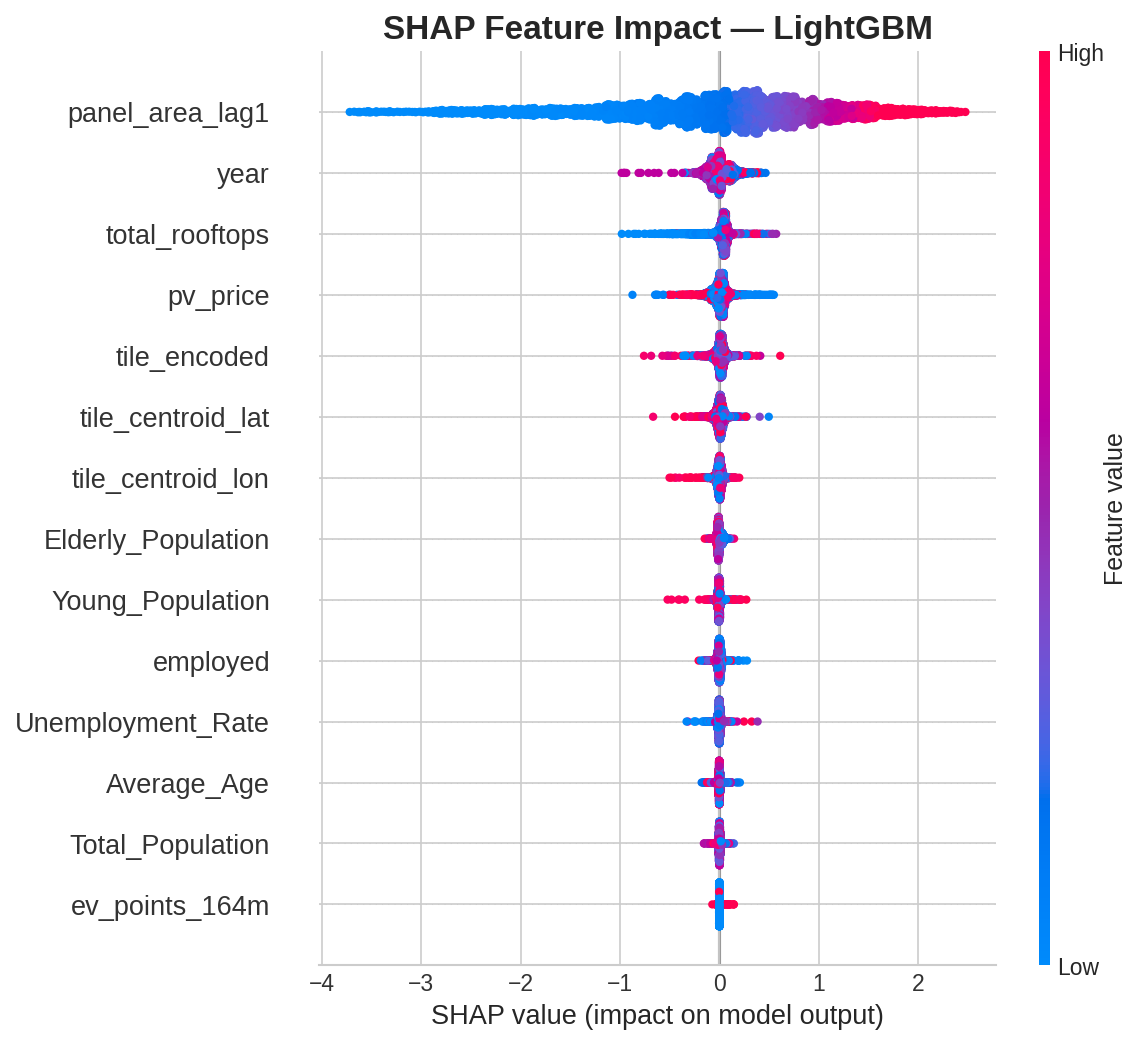

  Saved: shap_beeswarm_histgbr.png / .pdf


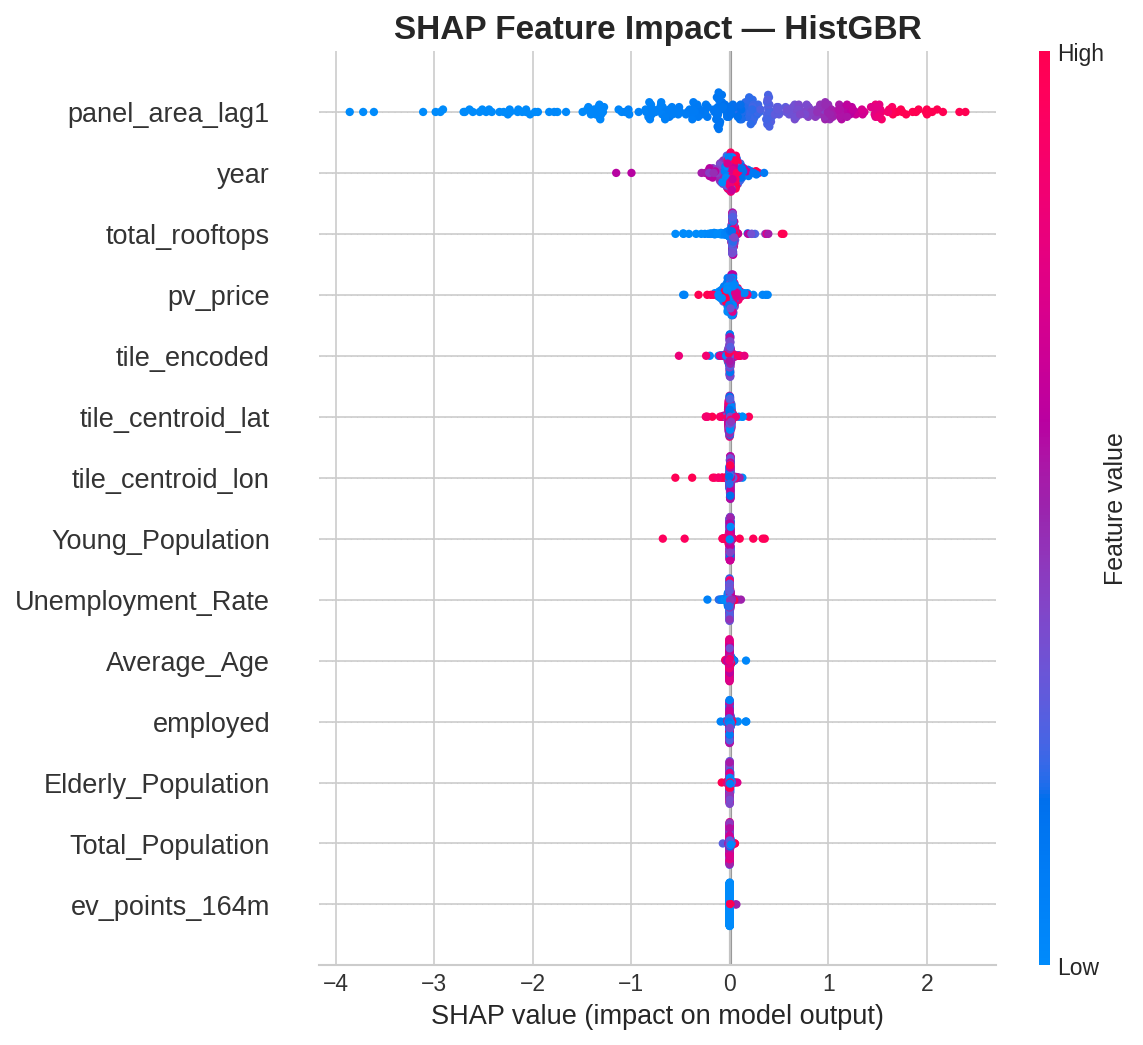

  Saved: shap_beeswarm_catboost.png / .pdf


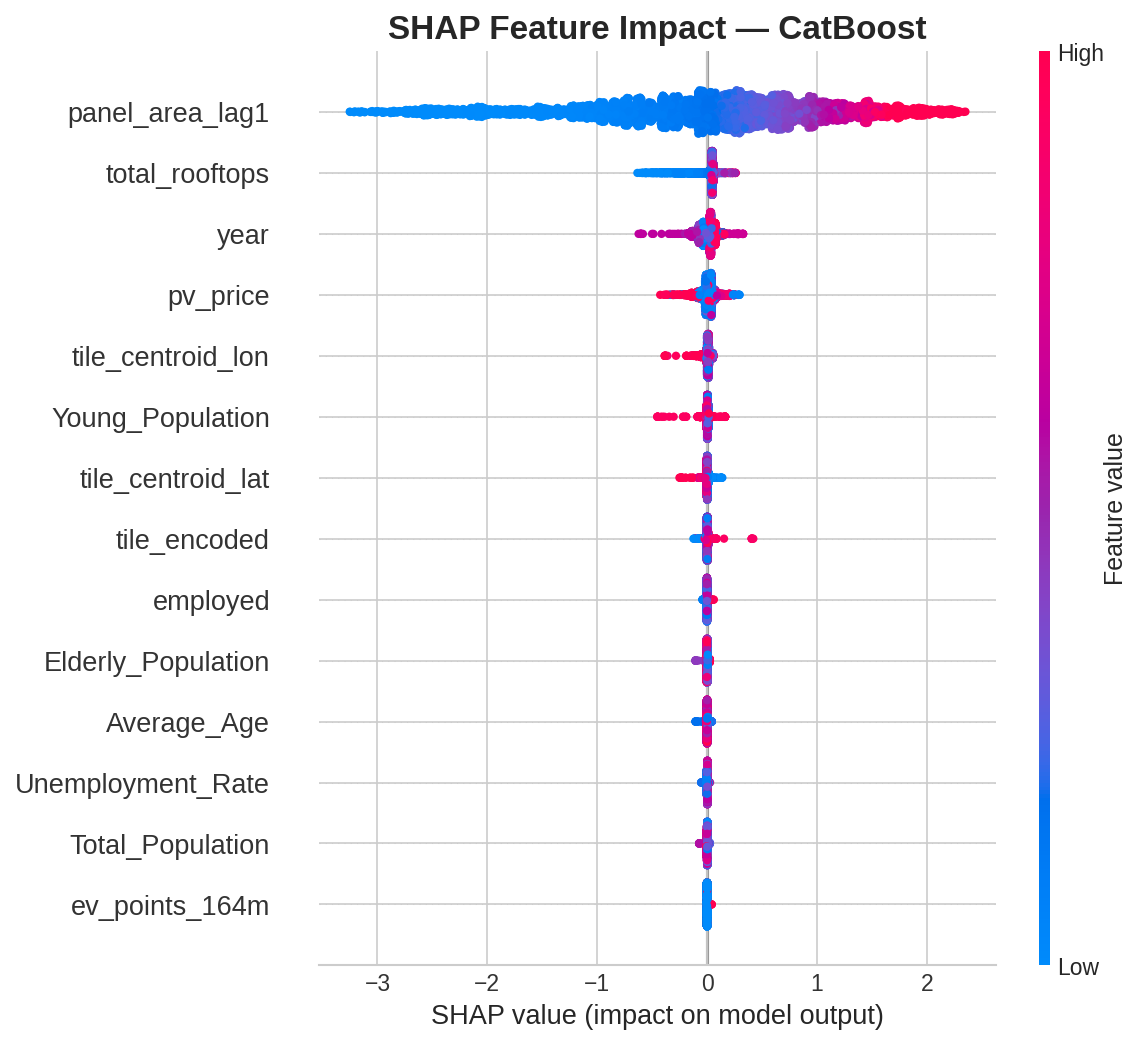

In [6]:
for name, sv in shap_results.items():
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.plots.beeswarm(sv, max_display=14, show=False)
    plt.title(f'SHAP Feature Impact — {name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_fig(fig, f'shap_beeswarm_{name.lower()}')
    plt.show()

---
### Figure 2: SHAP Mean Absolute Values — All Models Comparison

This shows the average |SHAP value| per feature for each model,
directly comparable to the feature importance from `model_results_analysis.ipynb`.

In [7]:
# Build a comparison dataframe of mean |SHAP| values (normalised to %)
shap_importance_df = pd.DataFrame()
for name, sv in shap_results.items():
    mean_abs = np.abs(sv.values).mean(axis=0)
    total = mean_abs.sum()
    pct = (mean_abs / total) * 100
    shap_importance_df[name] = pct

shap_importance_df.index = FEATURE_COLS
shap_importance_df['Average'] = shap_importance_df.mean(axis=1)
shap_importance_df = shap_importance_df.sort_values('Average', ascending=False)

# Display table
print('SHAP Feature Importance (%, normalised):')
styled = shap_importance_df.style.format('{:.2f}%').background_gradient(
    cmap='YlOrRd', axis=None
)
display(styled)

SHAP Feature Importance (%, normalised):


,LightGBM,HistGBR,CatBoost,Average
panel_area_lag1,68.91%,75.64%,77.75%,74.10%
year,6.53%,6.87%,5.44%,6.28%
total_rooftops,5.97%,4.63%,7.06%,5.89%
pv_price,4.37%,4.23%,4.59%,4.40%
tile_encoded,3.19%,1.54%,0.57%,1.77%
tile_centroid_lon,1.84%,1.39%,1.37%,1.53%
tile_centroid_lat,2.44%,1.42%,0.61%,1.49%
Young_Population,1.19%,1.13%,0.84%,1.05%
Unemployment_Rate,1.08%,1.06%,0.30%,0.82%
Elderly_Population,1.49%,0.42%,0.36%,0.76%


  Saved: shap_importance_comparison_bar.png / .pdf


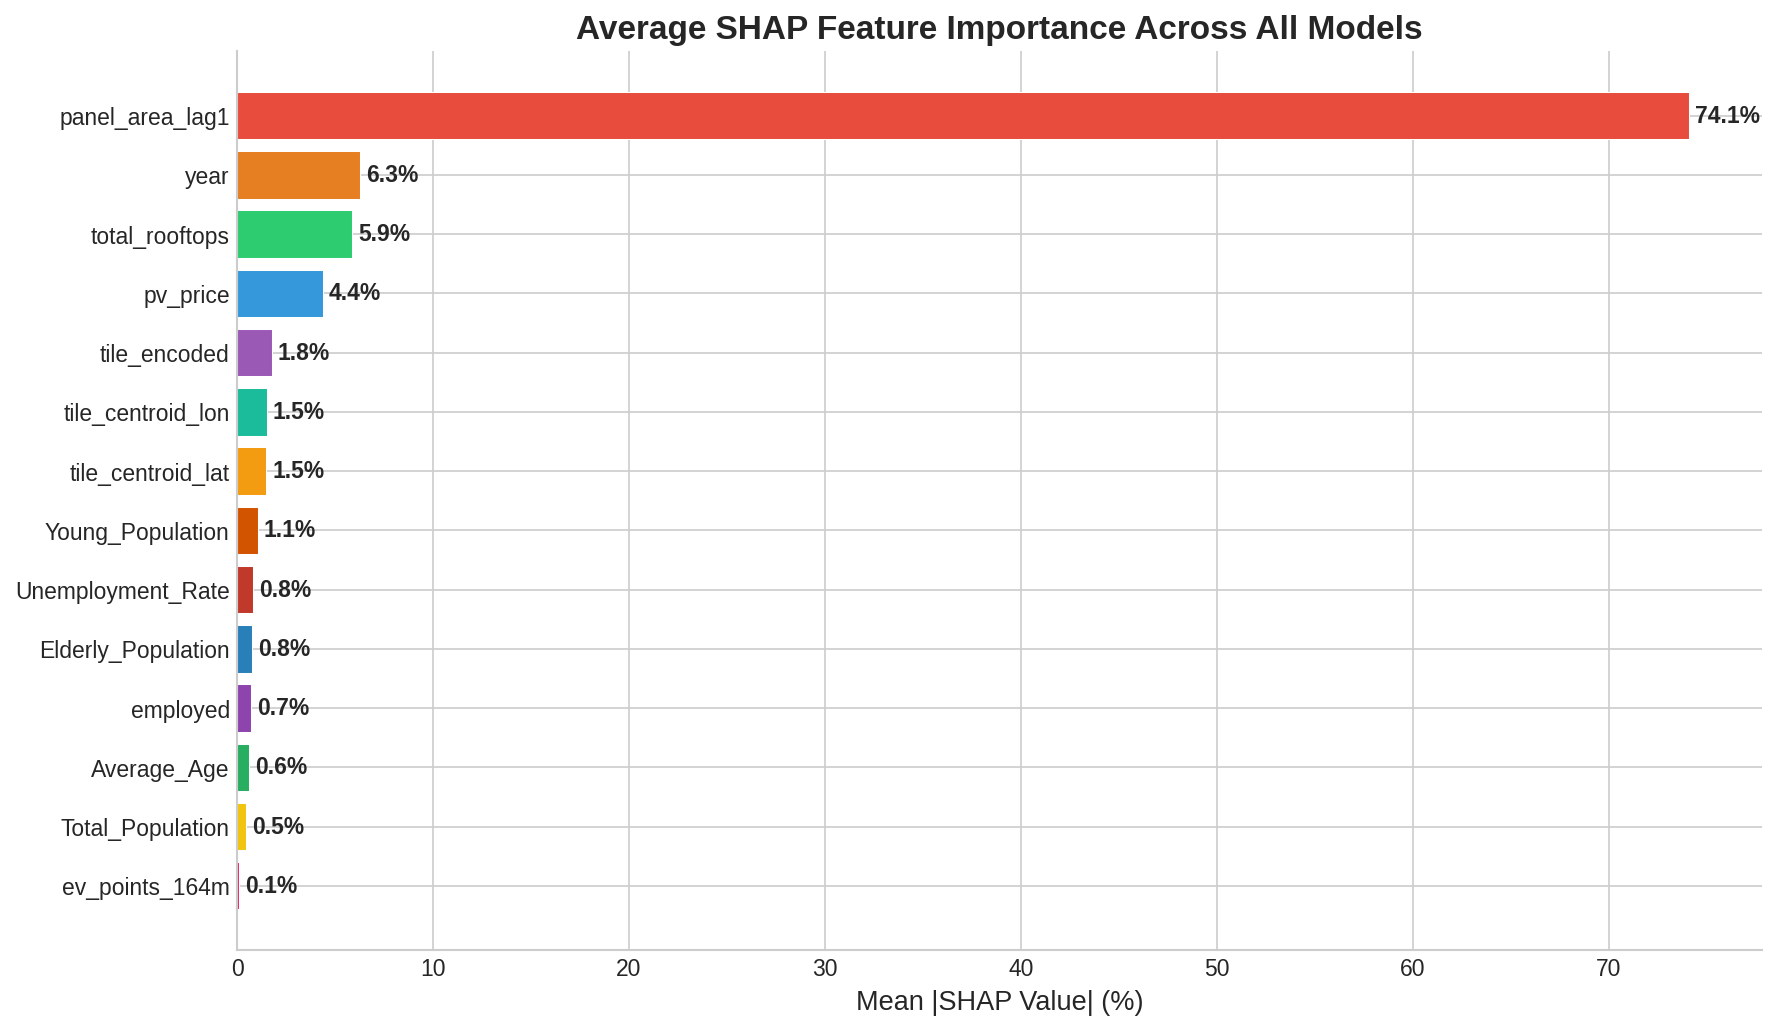

In [8]:
# Bar plot: Average SHAP importance across all models
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6',
          '#1abc9c', '#f39c12', '#d35400', '#c0392b', '#2980b9',
          '#8e44ad', '#27ae60', '#f1c40f', '#e91e63'][:len(shap_importance_df)]

bars = ax.barh(shap_importance_df.index[::-1],
               shap_importance_df['Average'].values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, shap_importance_df['Average'].values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Mean |SHAP Value| (%)', fontsize=13)
ax.set_title('Average SHAP Feature Importance Across All Models',
             fontsize=16, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

save_fig(fig, 'shap_importance_comparison_bar')
plt.show()

---
### Figure 3: SHAP vs Built-in Feature Importance — Side by Side

Shows how SHAP importance compares to traditional model feature importance.

  Saved: feature_importance_vs_shap_comparison.png / .pdf


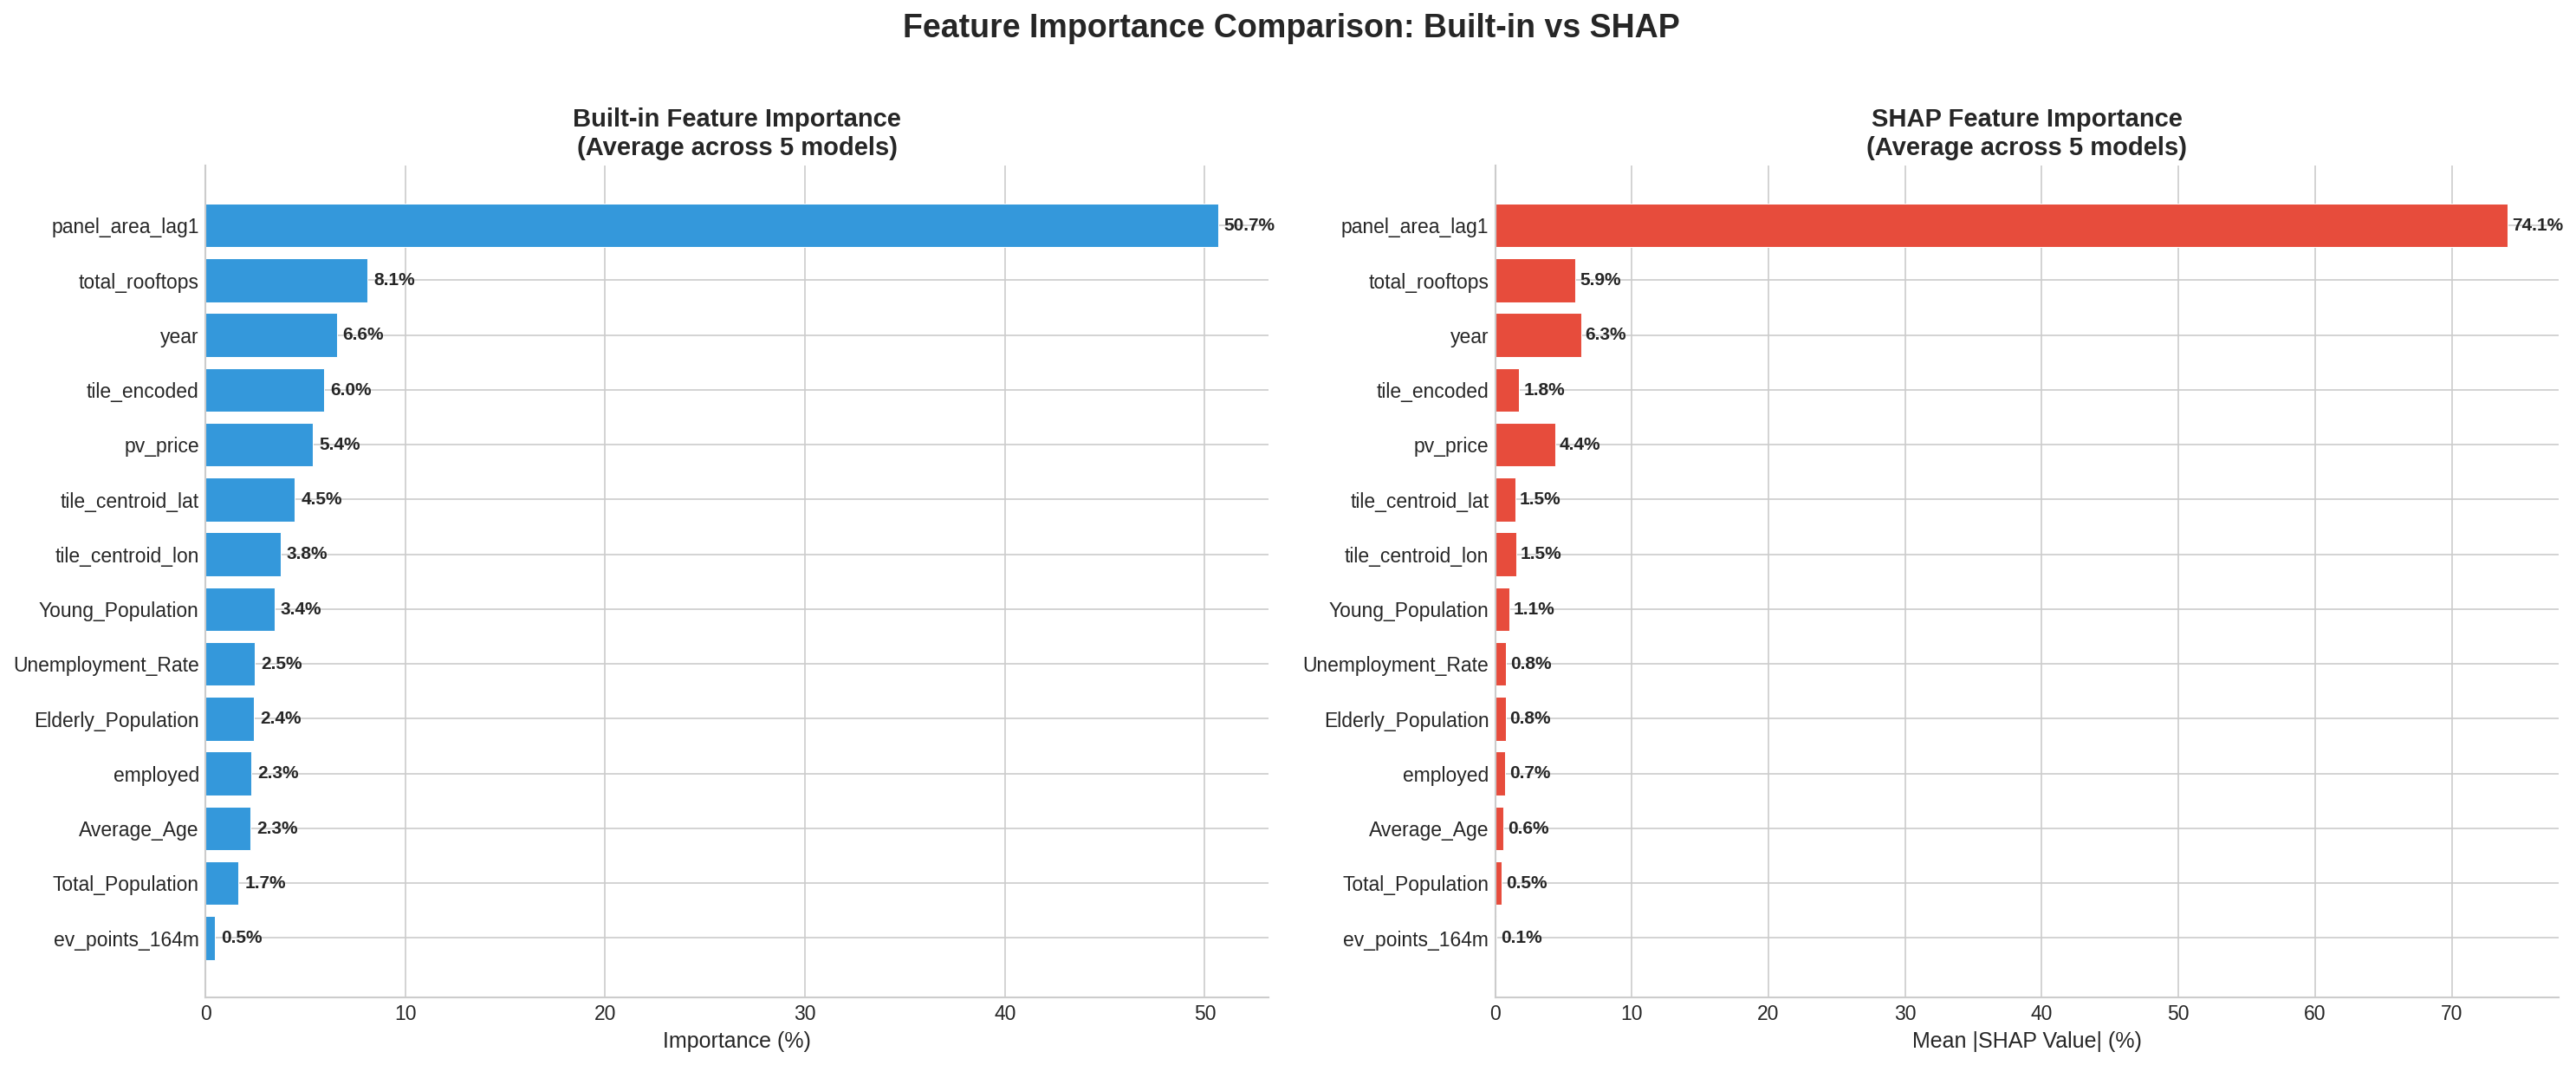

In [9]:
# Get built-in feature importance for tree models
builtin_importance = pd.DataFrame()
for name in model_names_tree:
    if name not in models:
        continue
    model = models[name]
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):
        imp = model.get_feature_importance()
    else:
        continue
    # Normalise to %
    total = imp.sum()
    pct = (imp / total) * 100
    builtin_importance[name] = pct

builtin_importance.index = FEATURE_COLS
builtin_importance['Average'] = builtin_importance.mean(axis=1)
builtin_importance = builtin_importance.sort_values('Average', ascending=False)

# Side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Left: Built-in importance
features_sorted = builtin_importance.index.tolist()
vals1 = builtin_importance['Average'].values
bars1 = ax1.barh(features_sorted[::-1], vals1[::-1], color='#3498db',
                 edgecolor='white', linewidth=0.5)
for bar, val in zip(bars1, vals1[::-1]):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
ax1.set_xlabel('Importance (%)', fontsize=12)
ax1.set_title('Built-in Feature Importance\n(Average across 5 models)',
              fontsize=14, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: SHAP importance
shap_sorted = shap_importance_df.reindex(features_sorted)
vals2 = shap_sorted['Average'].values
bars2 = ax2.barh(features_sorted[::-1], vals2[::-1], color='#e74c3c',
                 edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, vals2[::-1]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
ax2.set_xlabel('Mean |SHAP Value| (%)', fontsize=12)
ax2.set_title('SHAP Feature Importance\n(Average across 5 models)',
              fontsize=14, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Feature Importance Comparison: Built-in vs SHAP',
             fontsize=18, fontweight='bold', y=1.02)

save_fig(fig, 'feature_importance_vs_shap_comparison')
plt.show()

---
### Figure 4: SHAP Dependence Plots — Top Features

Shows how each feature value affects the prediction, with interactions highlighted.

  Saved: shap_dependence_top6.png / .pdf


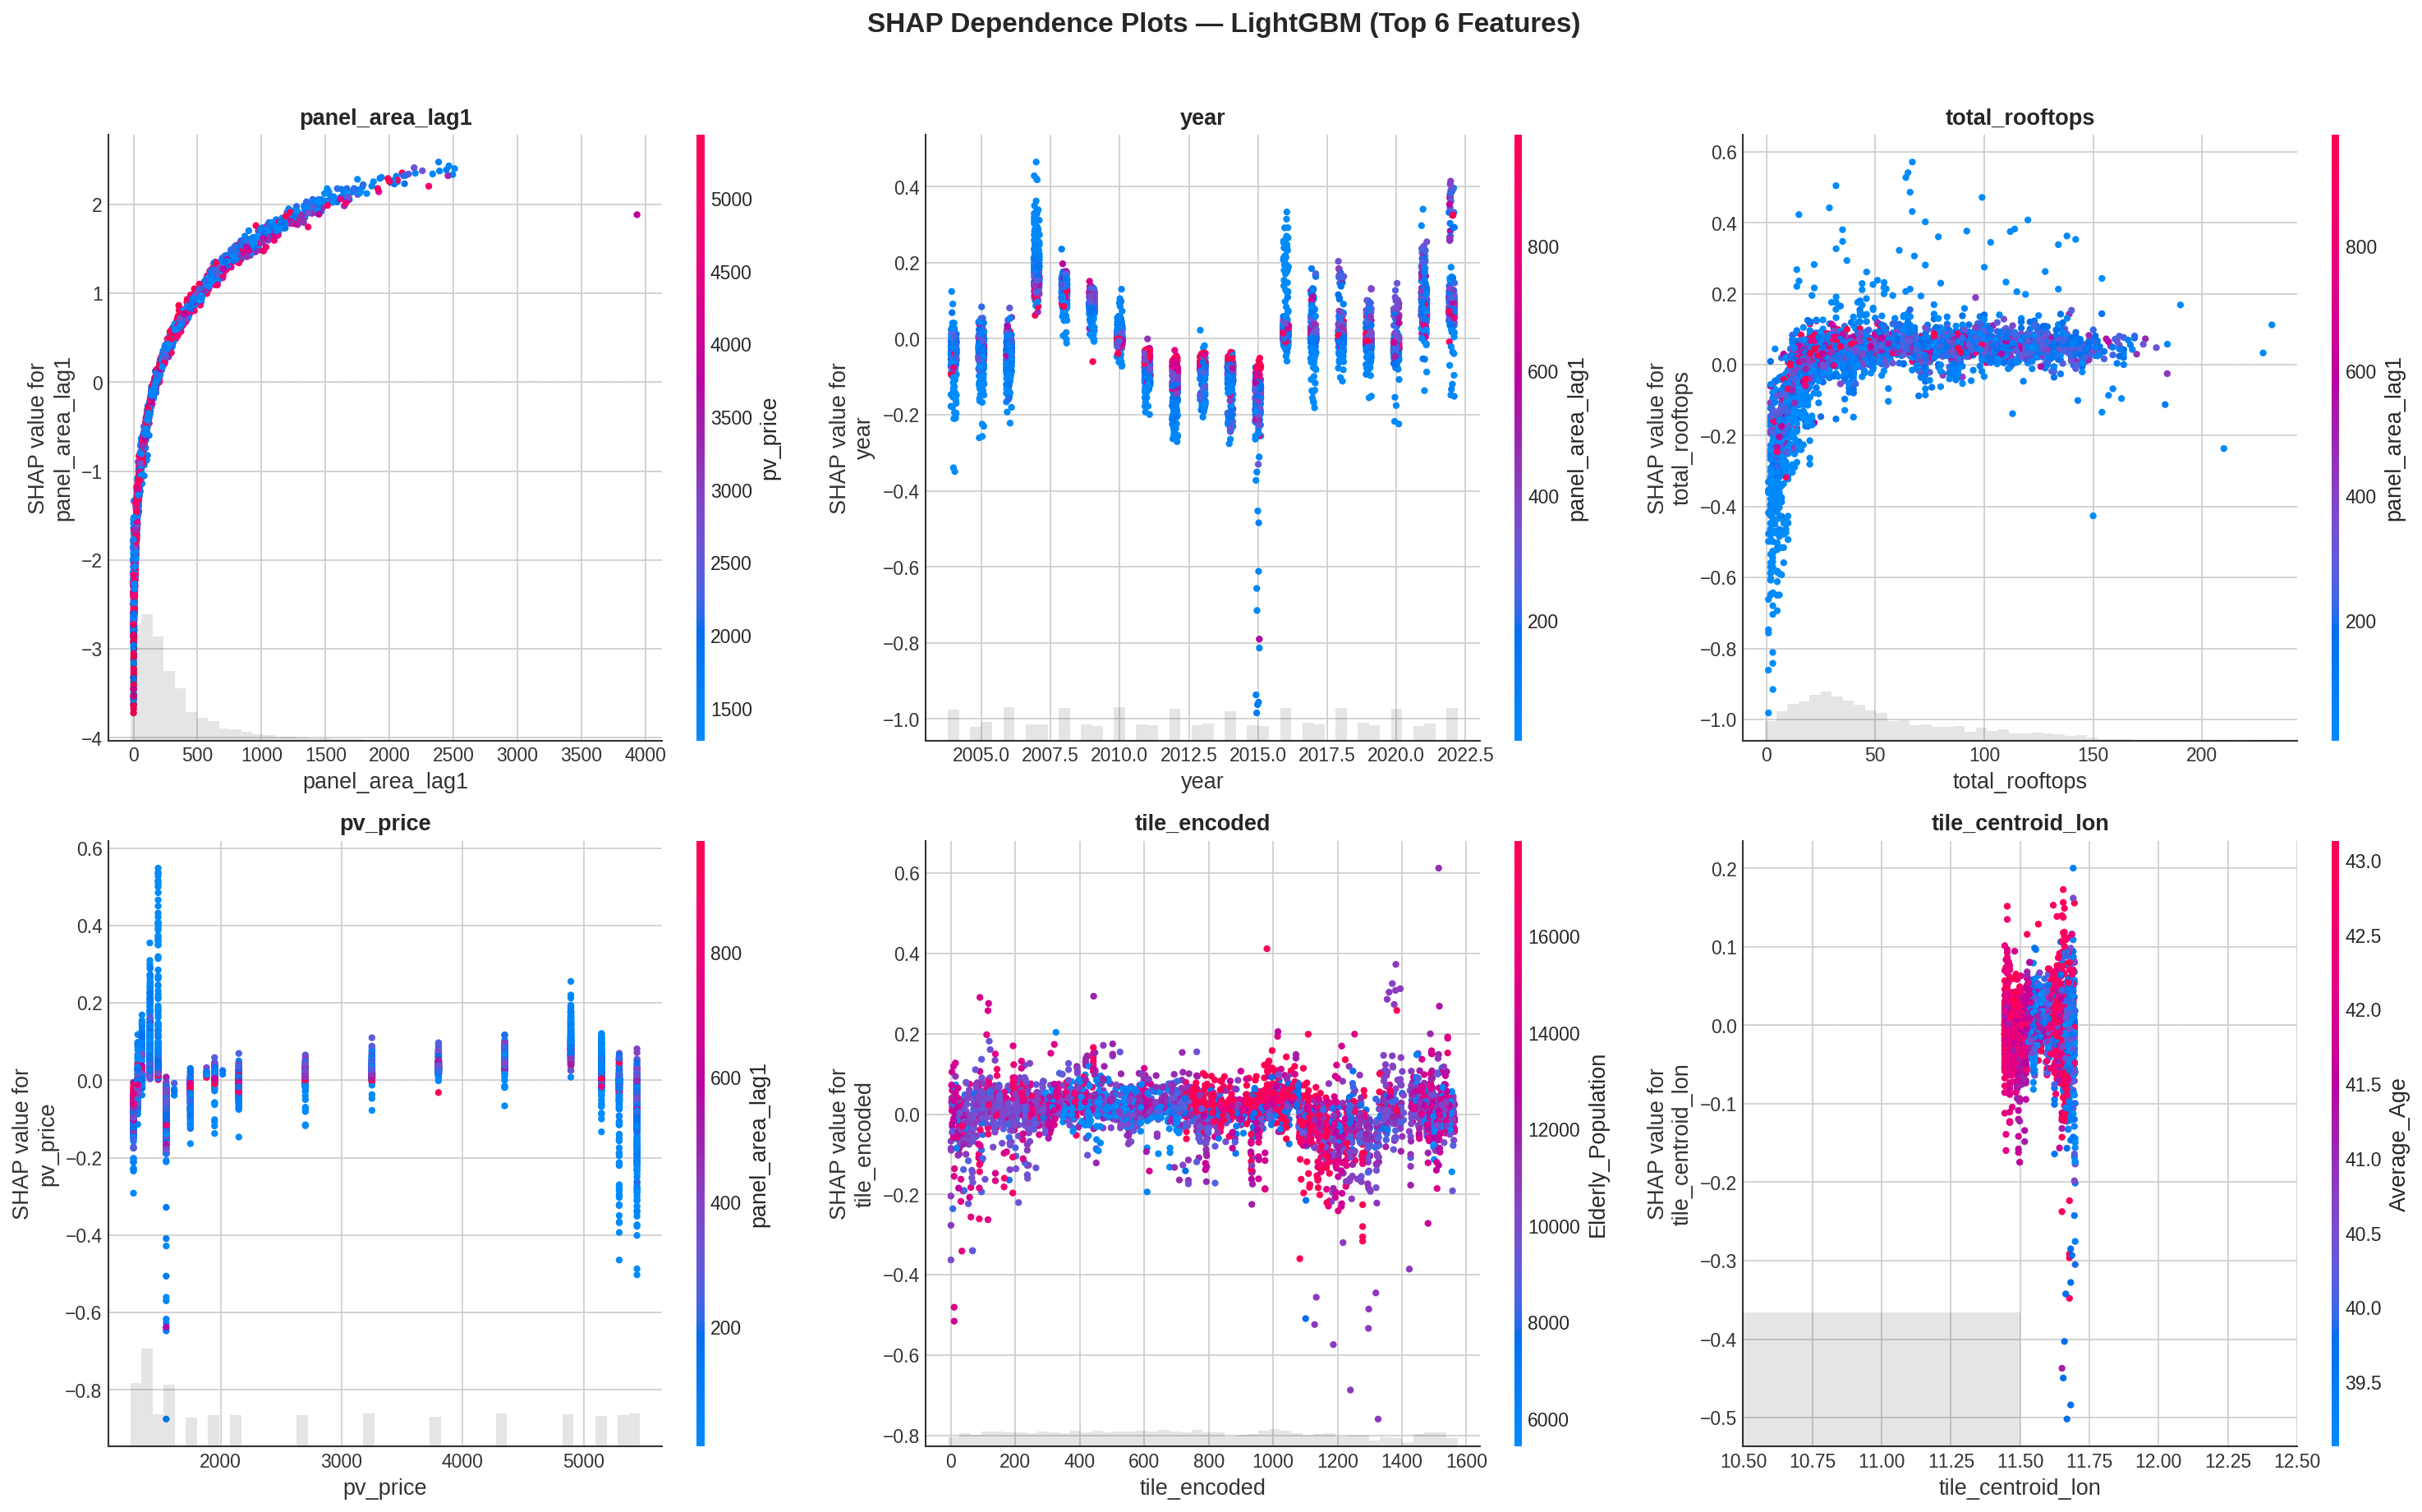

In [10]:
# Use LightGBM as representative model
sv = shap_results.get('LightGBM') or list(shap_results.values())[0]
model_label = 'LightGBM' if 'LightGBM' in shap_results else list(shap_results.keys())[0]

# Top 6 features by SHAP importance
top_features = shap_importance_df.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

for i, feat in enumerate(top_features):
    feat_idx = FEATURE_COLS.index(feat)
    shap.plots.scatter(sv[:, feat_idx], color=sv, ax=axes_flat[i], show=False)
    axes_flat[i].set_title(f'{feat}', fontsize=13, fontweight='bold')

plt.suptitle(f'SHAP Dependence Plots — {model_label} (Top 6 Features)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'shap_dependence_top6', tight=False)
plt.show()

---
### Figure 5: Per-Model SHAP Importance — Grid View

  Saved: shap_per_model_grid.png / .pdf


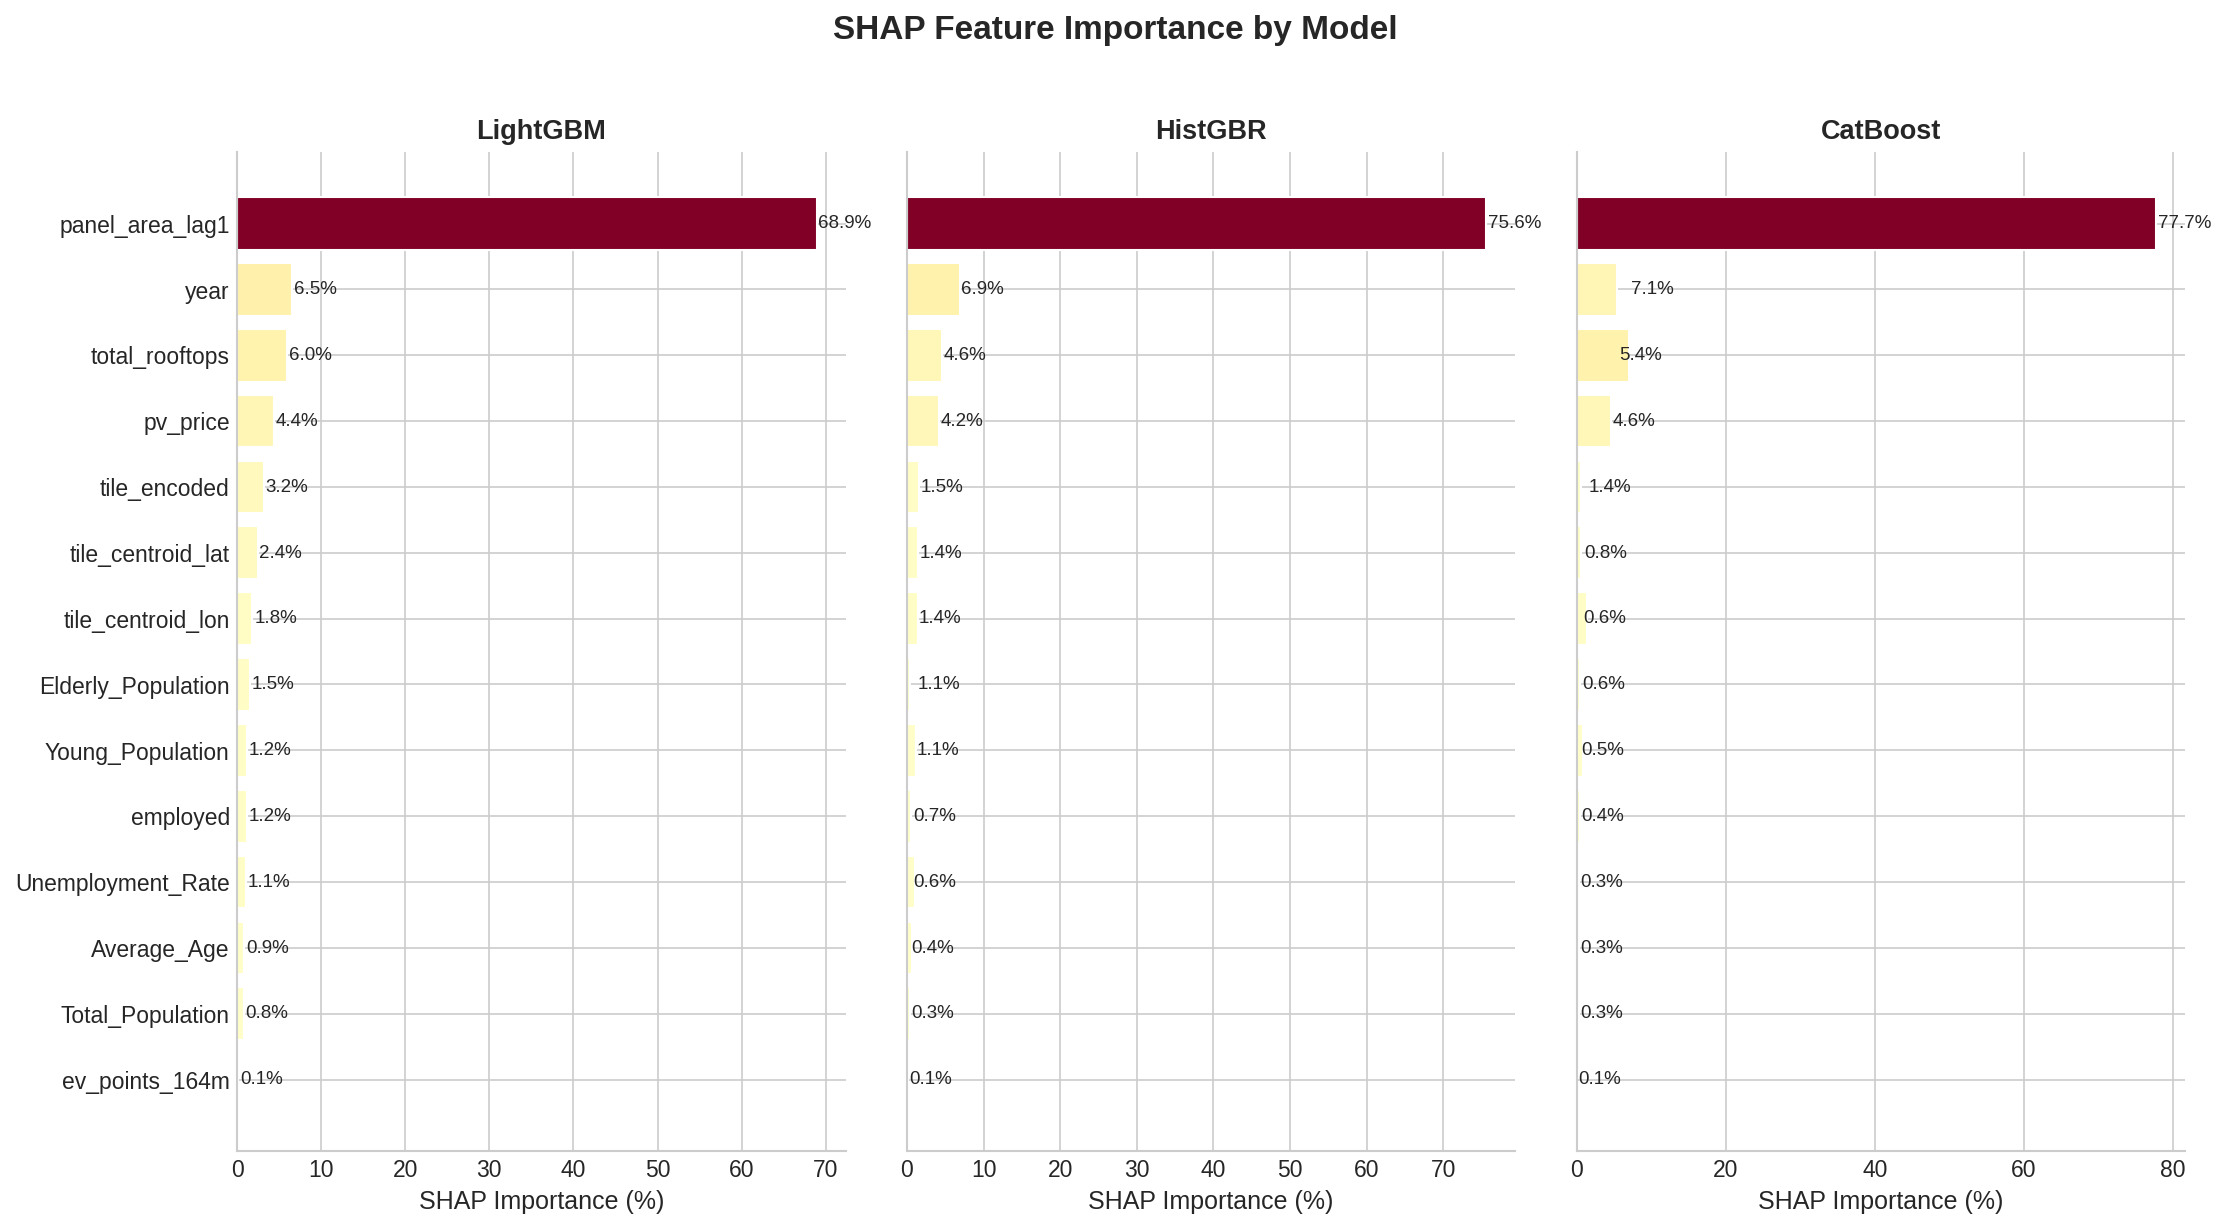

In [11]:
n_models = len(shap_results)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 8), sharey=True)

if n_models == 1:
    axes = [axes]

for ax, (name, sv) in zip(axes, shap_results.items()):
    mean_abs = np.abs(sv.values).mean(axis=0)
    total = mean_abs.sum()
    pct = (mean_abs / total) * 100

    # Sort
    order = np.argsort(pct)
    features_sorted_local = [FEATURE_COLS[i] for i in order]
    pct_sorted = pct[order]

    colors_bar = plt.cm.YlOrRd(pct_sorted / pct_sorted.max())
    ax.barh(features_sorted_local, pct_sorted, color=colors_bar, edgecolor='white')

    for j, (f, v) in enumerate(zip(features_sorted_local, pct_sorted)):
        ax.text(v + 0.2, j, f'{v:.1f}%', va='center', fontsize=9)

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('SHAP Importance (%)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('SHAP Feature Importance by Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'shap_per_model_grid', tight=False)
plt.show()

---
## 4. Prediction Quality Analysis

### Figure 6: Predicted vs Actual — All Models

KeyboardInterrupt: 

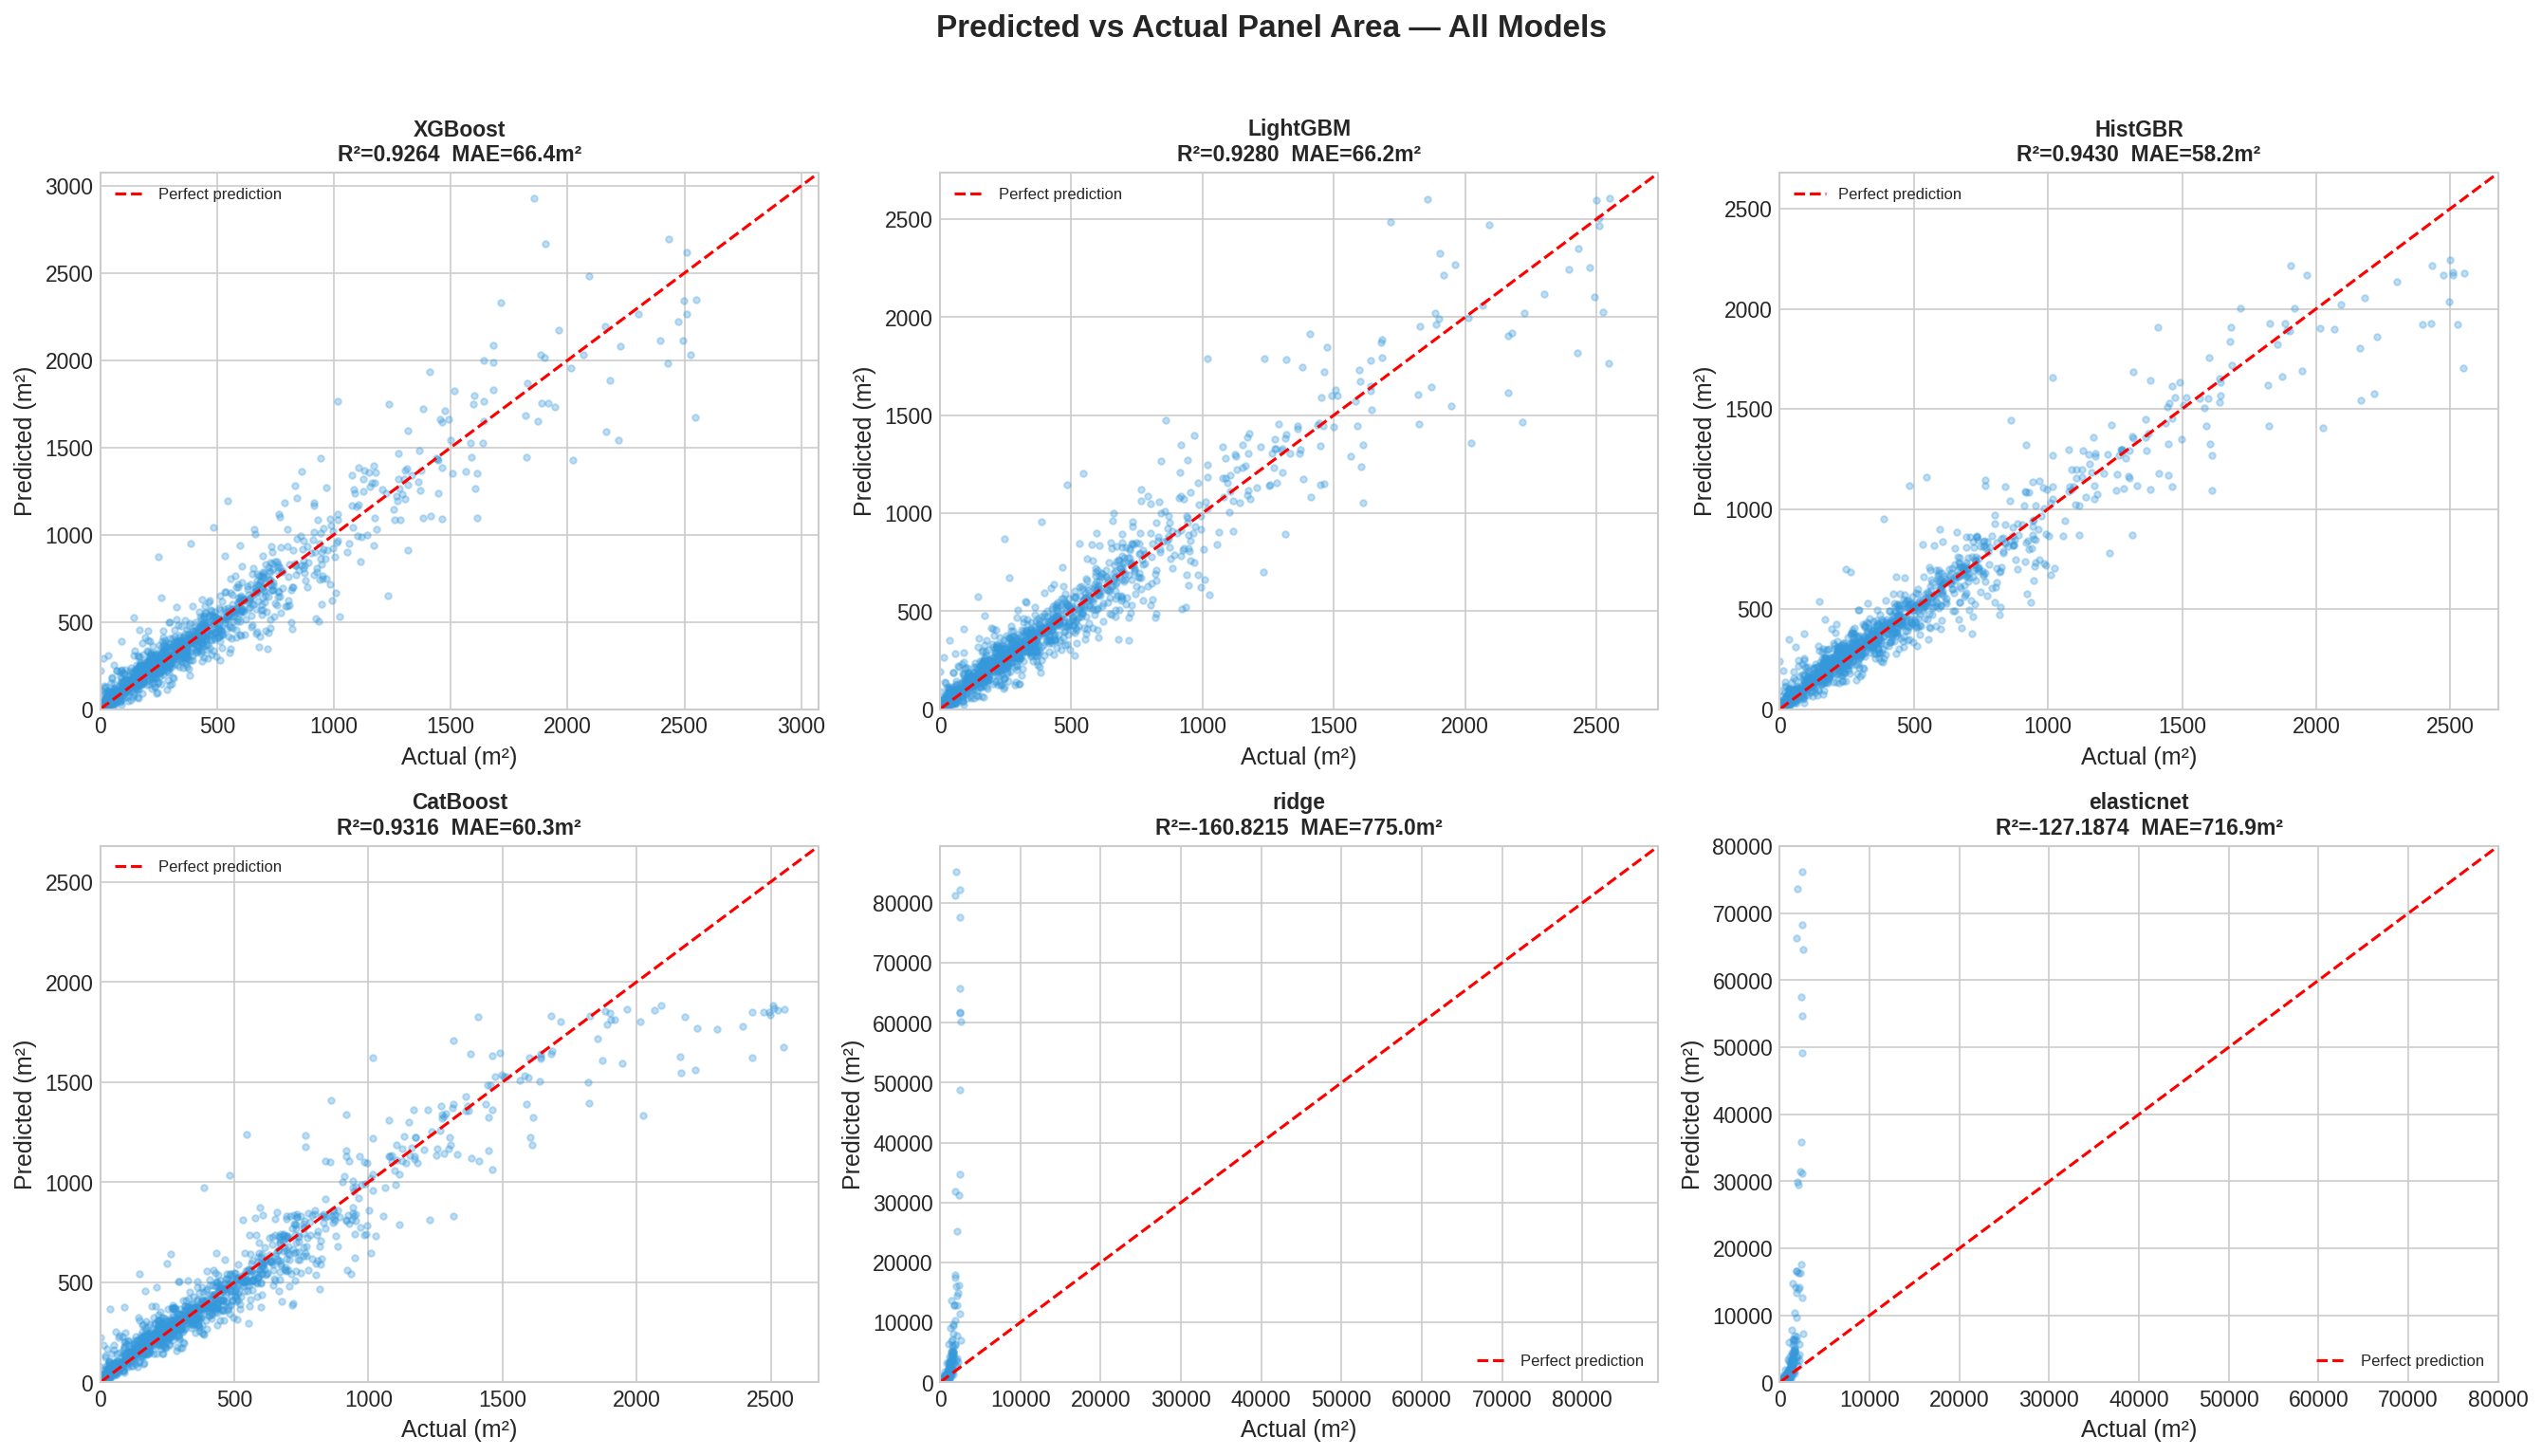

In [12]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

n_models = len(models)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes_flat = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    ax = axes_flat[i]
    y_pred = model.predict(X_test)
    y_pred_real = np.clip(np.expm1(y_pred), 0, None)
    y_test_real = np.expm1(y_test.values)

    ax.scatter(y_test_real, y_pred_real, alpha=0.3, s=10, c='#3498db')
    lims = [0, max(y_test_real.max(), y_pred_real.max()) * 1.05]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual (m²)')
    ax.set_ylabel('Predicted (m²)')

    r2 = r2_score(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    ax.set_title(f'{name}\nR²={r2:.4f}  MAE={mae:.1f}m²',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Predicted vs Actual Panel Area — All Models',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'predicted_vs_actual_all_models', tight=False)
plt.show()

---
### Figure 7: Residual Distribution — All Models

  Saved: residual_distribution_all_models.png / .pdf


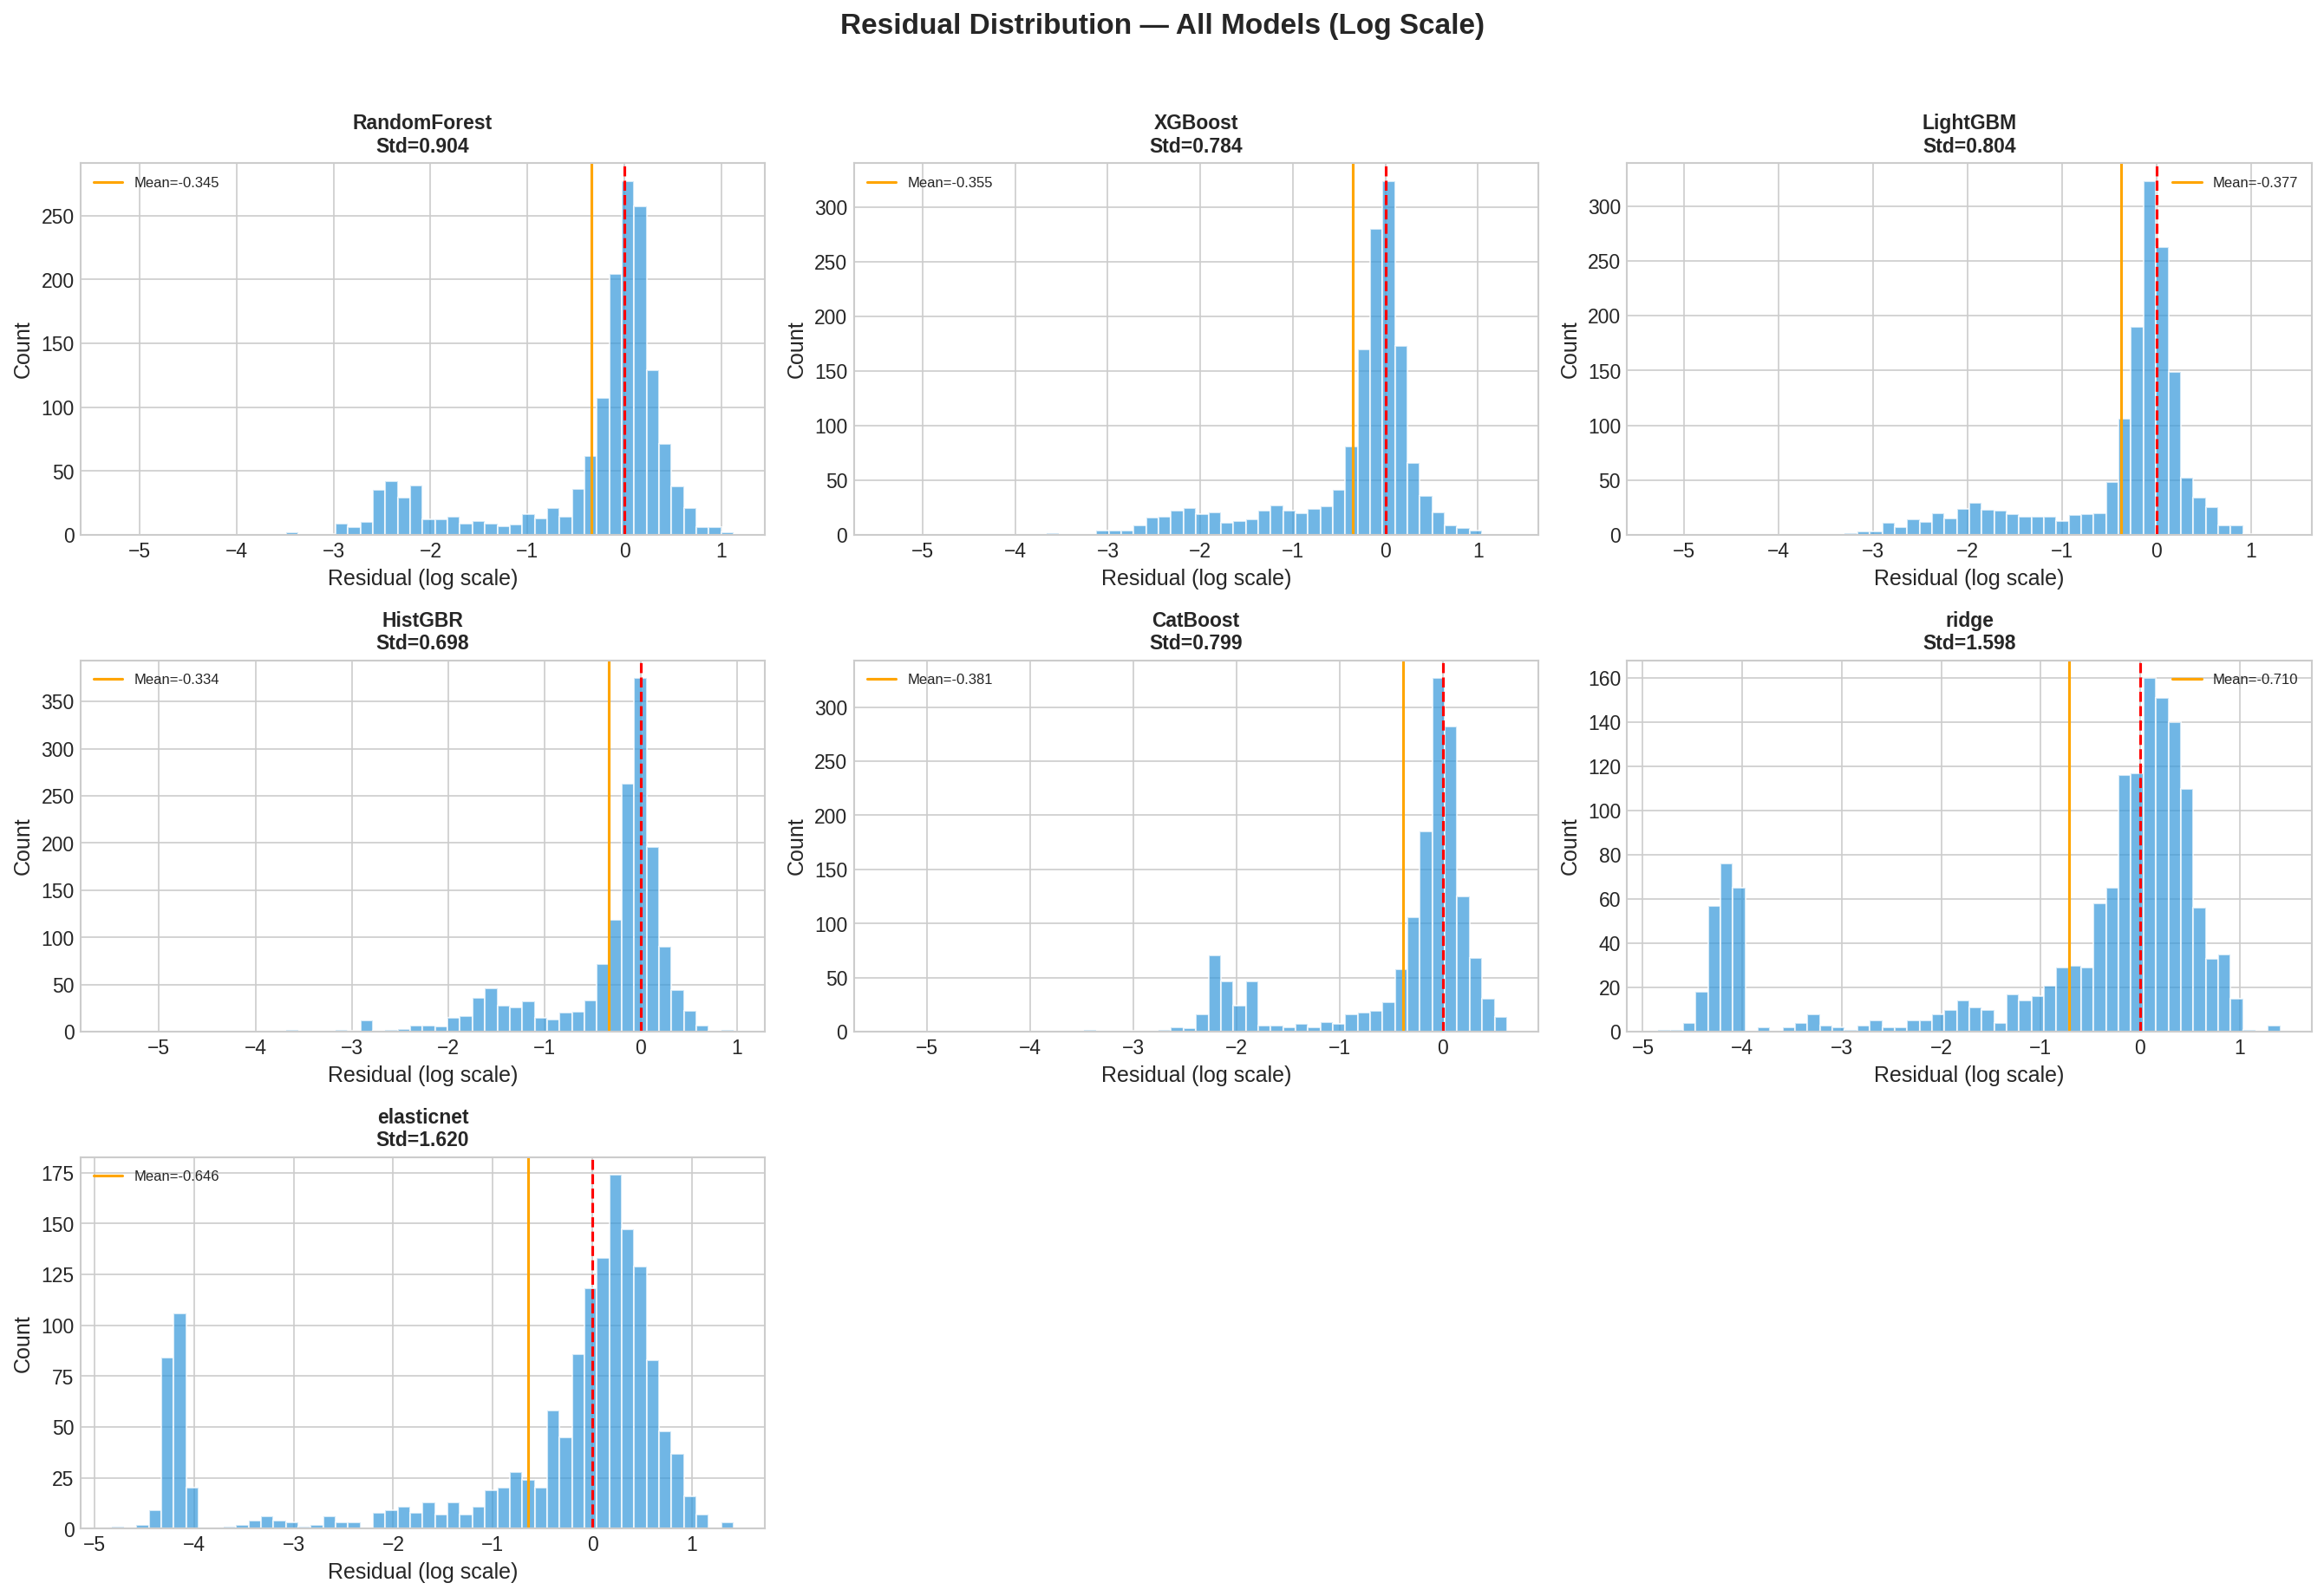

In [ ]:
ncols = 3
nrows = (len(models) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes_flat = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    ax = axes_flat[i]
    y_pred = model.predict(X_test)
    residuals = y_test.values - y_pred

    ax.hist(residuals, bins=50, color='#3498db', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(np.mean(residuals), color='orange', linestyle='-', linewidth=1.5,
               label=f'Mean={np.mean(residuals):.3f}')
    ax.set_xlabel('Residual (log scale)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}\nStd={np.std(residuals):.3f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Residual Distribution — All Models (Log Scale)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'residual_distribution_all_models', tight=False)
plt.show()

---
### Figure 8: Absolute Error vs Key Features

Shows how prediction errors relate to feature values, revealing model weaknesses.

  Saved: error_vs_features.png / .pdf


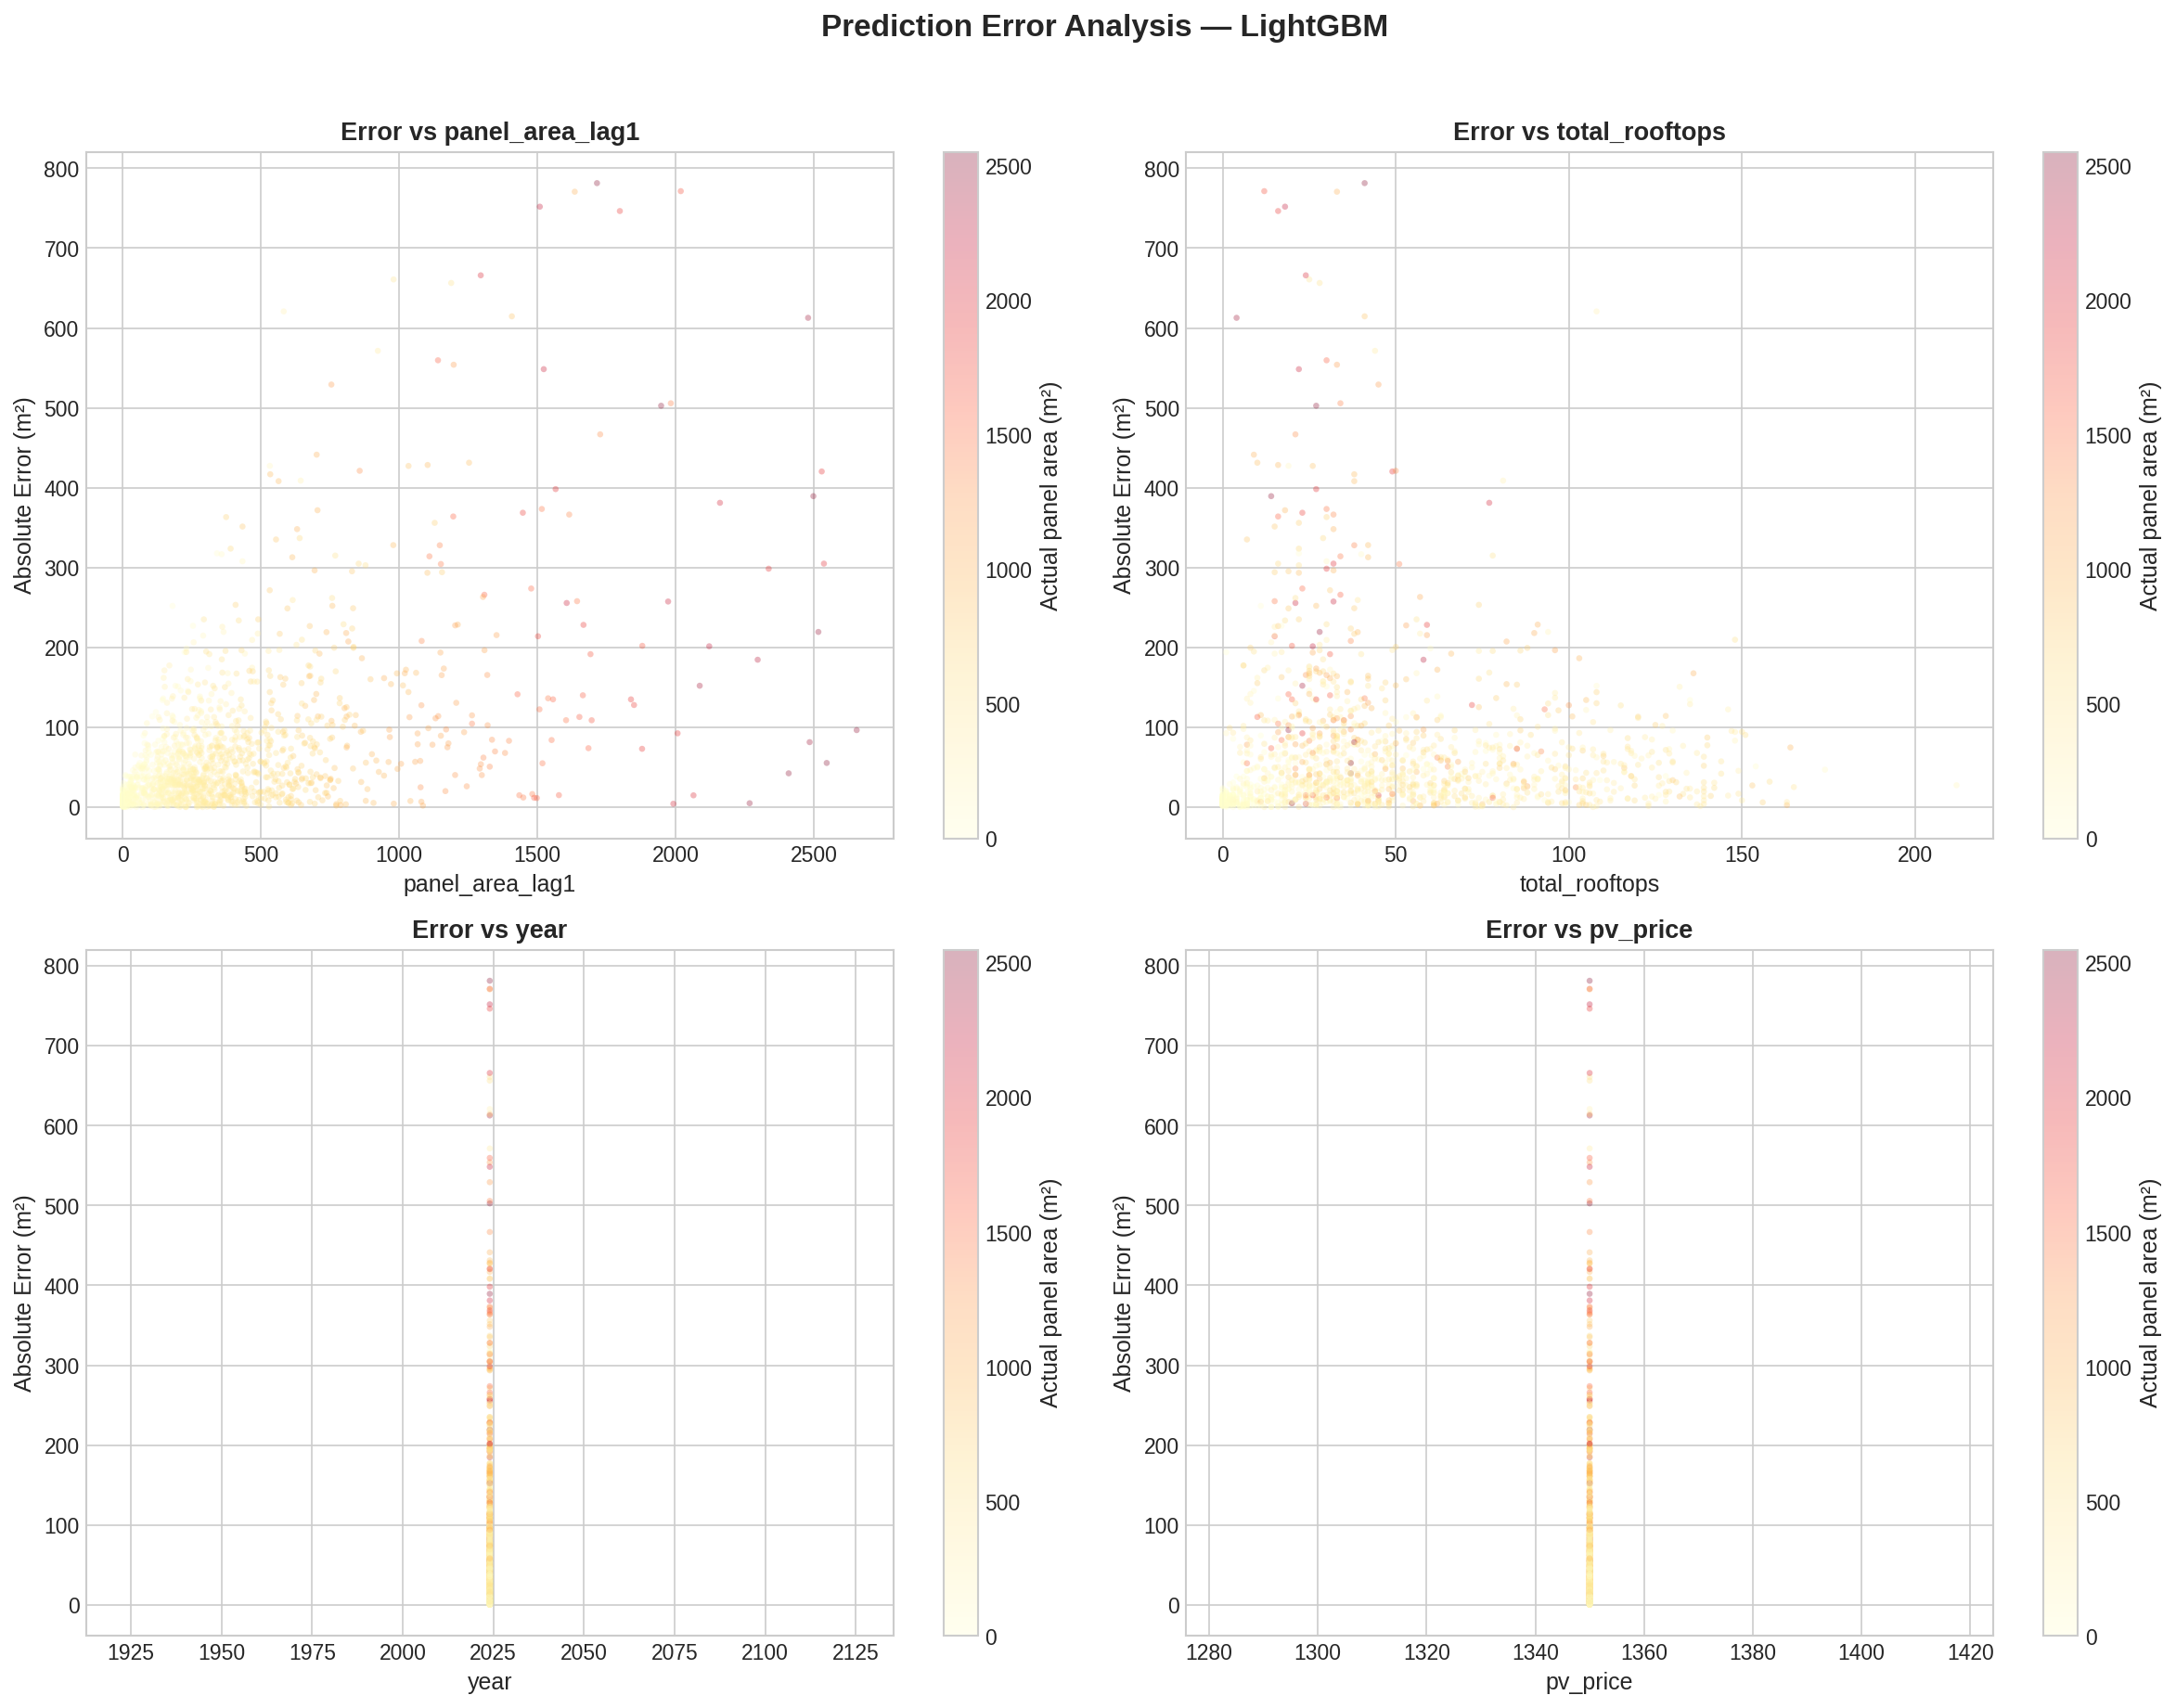

In [ ]:
# Use best model (LightGBM)
best_model_name = 'LightGBM' if 'LightGBM' in models else list(models.keys())[0]
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)
y_pred_real = np.clip(np.expm1(y_pred), 0, None)
y_test_real = np.expm1(y_test.values)
abs_error = np.abs(y_test_real - y_pred_real)

# Create error analysis dataframe
error_df = X_test.copy()
error_df['abs_error'] = abs_error
error_df['actual'] = y_test_real
error_df['predicted'] = y_pred_real

top4_features = shap_importance_df.index[:4].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

for i, feat in enumerate(top4_features):
    ax = axes_flat[i]
    scatter = ax.scatter(error_df[feat], error_df['abs_error'],
                        alpha=0.3, s=10, c=error_df['actual'],
                        cmap='YlOrRd', edgecolors='none')
    ax.set_xlabel(feat, fontsize=12)
    ax.set_ylabel('Absolute Error (m²)', fontsize=12)
    ax.set_title(f'Error vs {feat}', fontweight='bold', fontsize=13)
    plt.colorbar(scatter, ax=ax, label='Actual panel area (m²)')

plt.suptitle(f'Prediction Error Analysis — {best_model_name}',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'error_vs_features', tight=False)
plt.show()

---
### Figure 9: Model Performance Comparison

In [ ]:
results = []
for name, model in models.items():
    y_pred_log = model.predict(X_test)
    y_pred_real = np.clip(np.expm1(y_pred_log), 0, None)
    y_test_real = np.expm1(y_test.values)

    results.append({
        'Model': name,
        'R2_log': r2_score(y_test, y_pred_log),
        'RMSE_log': rmse(y_test, y_pred_log),
        'R2_real': r2_score(y_test_real, y_pred_real),
        'MAE_real': mean_absolute_error(y_test_real, y_pred_real),
        'RMSE_real': rmse(y_test_real, y_pred_real),
    })

results_df = pd.DataFrame(results).sort_values('MAE_real')
results_df.index = range(1, len(results_df) + 1)
results_df.index.name = 'Rank'

# Styled table
styled = results_df.style.format({
    'R2_log': '{:.4f}',
    'RMSE_log': '{:.4f}',
    'R2_real': '{:.4f}',
    'MAE_real': '{:.2f}',
    'RMSE_real': '{:.2f}',
}).background_gradient(
    subset=['MAE_real'], cmap='RdYlGn_r', low=0, high=0.5
).background_gradient(
    subset=['R2_real'], cmap='RdYlGn', low=0, high=0.3
)
display(styled)

,Model,R2_log,RMSE_log,R2_real,MAE_real,RMSE_real
Rank,,,,,,
1,HistGBR,0.8827,0.7740,0.9430,58.20,104.38
2,CatBoost,0.8466,0.8850,0.9316,60.28,114.35
3,LightGBM,0.8455,0.8883,0.9280,66.19,117.34
4,XGBoost,0.8548,0.8608,0.9264,66.38,118.66
5,RandomForest,0.8166,0.9675,0.8426,84.71,173.53
6,elasticnet,0.4042,1.7441,-127.1874,716.90,4951.64
7,ridge,0.4012,1.7484,-160.8215,775.02,5563.46


  Saved: model_performance_comparison.png / .pdf


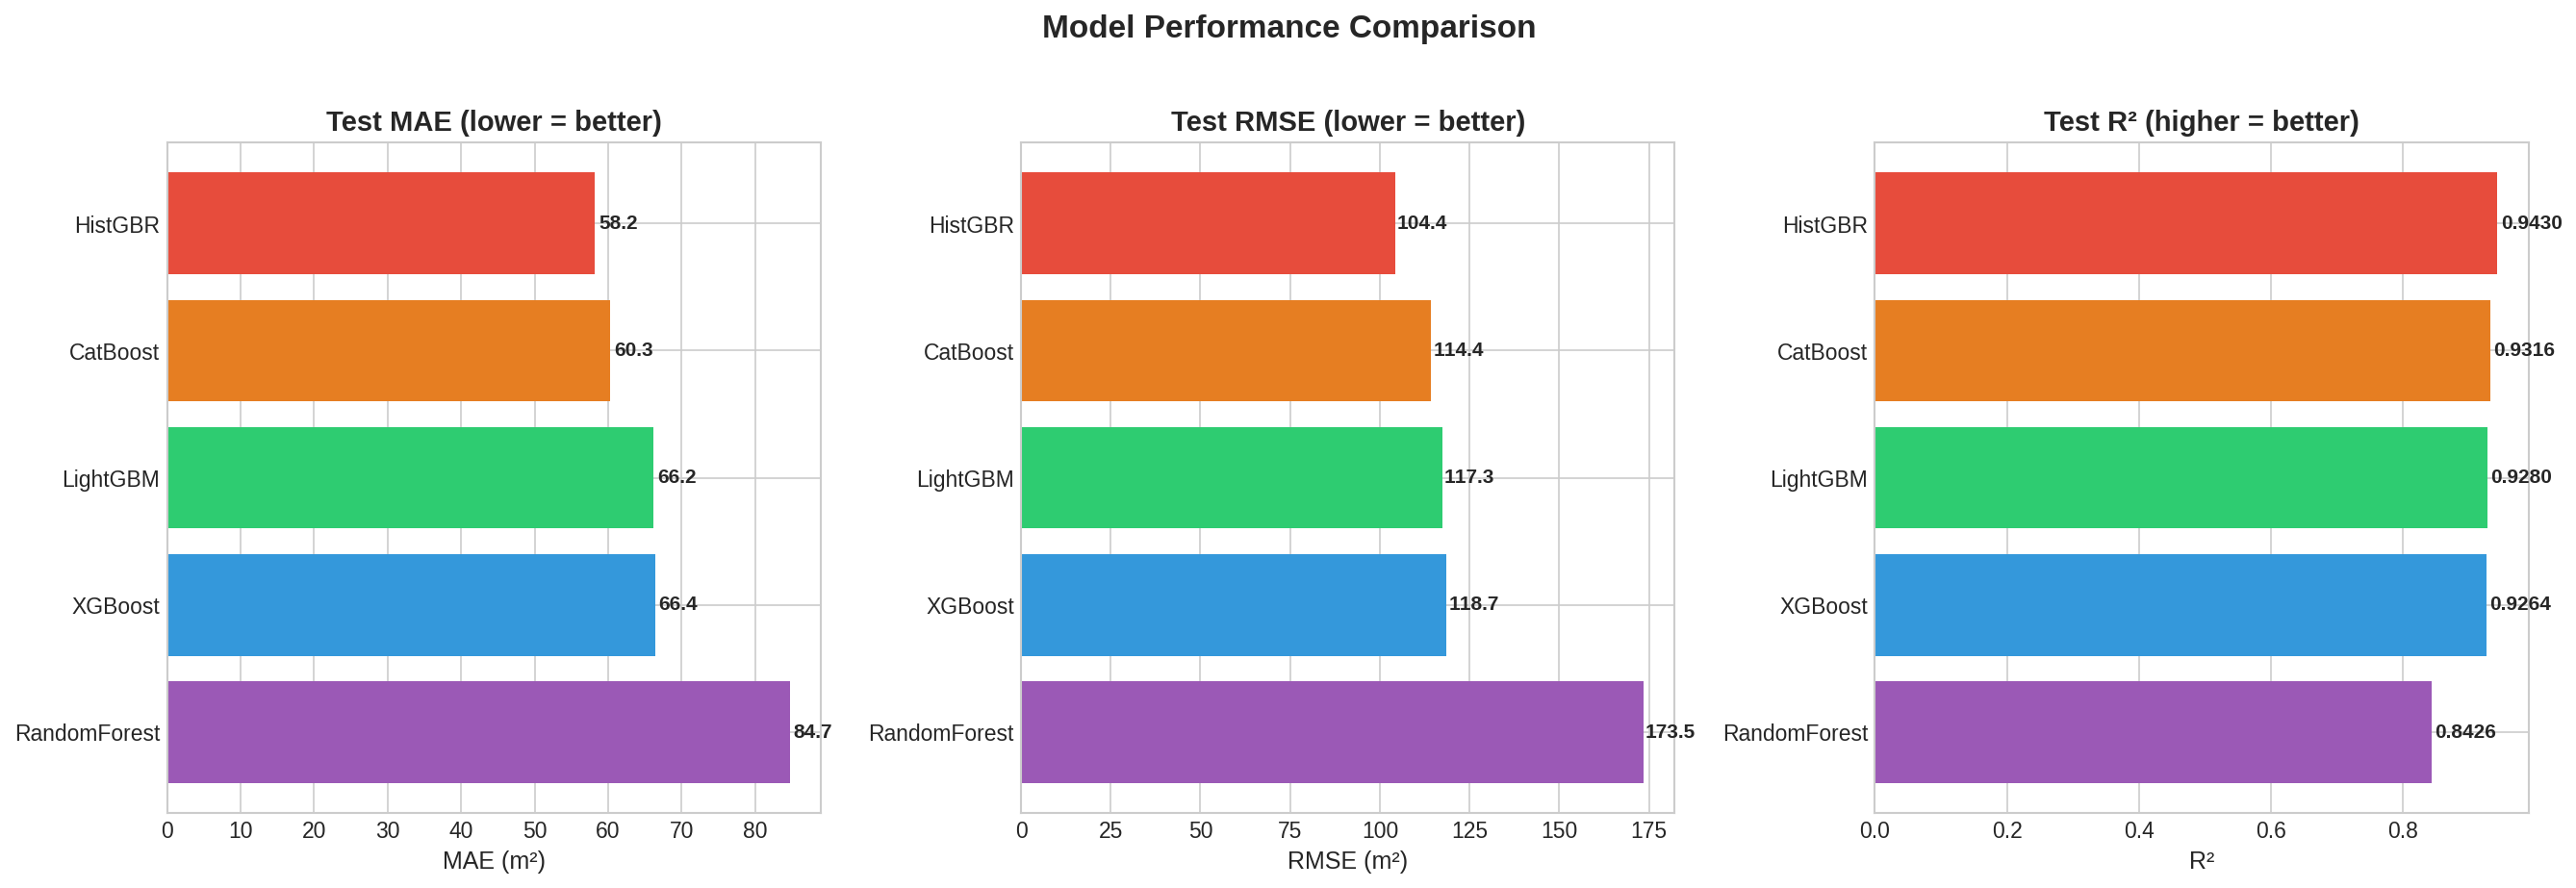

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6', '#1abc9c', '#f39c12']

# Filter out models with extreme values
plot_df = results_df[results_df['R2_real'] > -1].copy()

# MAE
sorted_df = plot_df.sort_values('MAE_real')
bars = axes[0].barh(sorted_df['Model'], sorted_df['MAE_real'],
                    color=colors[:len(sorted_df)])
axes[0].set_xlabel('MAE (m²)')
axes[0].set_title('Test MAE (lower = better)', fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, sorted_df['MAE_real']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontweight='bold', fontsize=10)

# RMSE
sorted_rmse = plot_df.sort_values('RMSE_real')
bars = axes[1].barh(sorted_rmse['Model'], sorted_rmse['RMSE_real'],
                    color=colors[:len(sorted_rmse)])
axes[1].set_xlabel('RMSE (m²)')
axes[1].set_title('Test RMSE (lower = better)', fontweight='bold')
axes[1].invert_yaxis()
for bar, val in zip(bars, sorted_rmse['RMSE_real']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontweight='bold', fontsize=10)

# R2
sorted_r2 = plot_df.sort_values('R2_real', ascending=False)
bars = axes[2].barh(sorted_r2['Model'], sorted_r2['R2_real'],
                    color=colors[:len(sorted_r2)])
axes[2].set_xlabel('R²')
axes[2].set_title('Test R² (higher = better)', fontweight='bold')
axes[2].invert_yaxis()
for bar, val in zip(bars, sorted_r2['R2_real']):
    axes[2].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontweight='bold', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'model_performance_comparison', tight=False)
plt.show()

---
### Figure 10: SHAP Waterfall — Individual Prediction Explanations

Shows how each feature contributes to a specific prediction.

  Saved: shap_waterfall_examples.png / .pdf


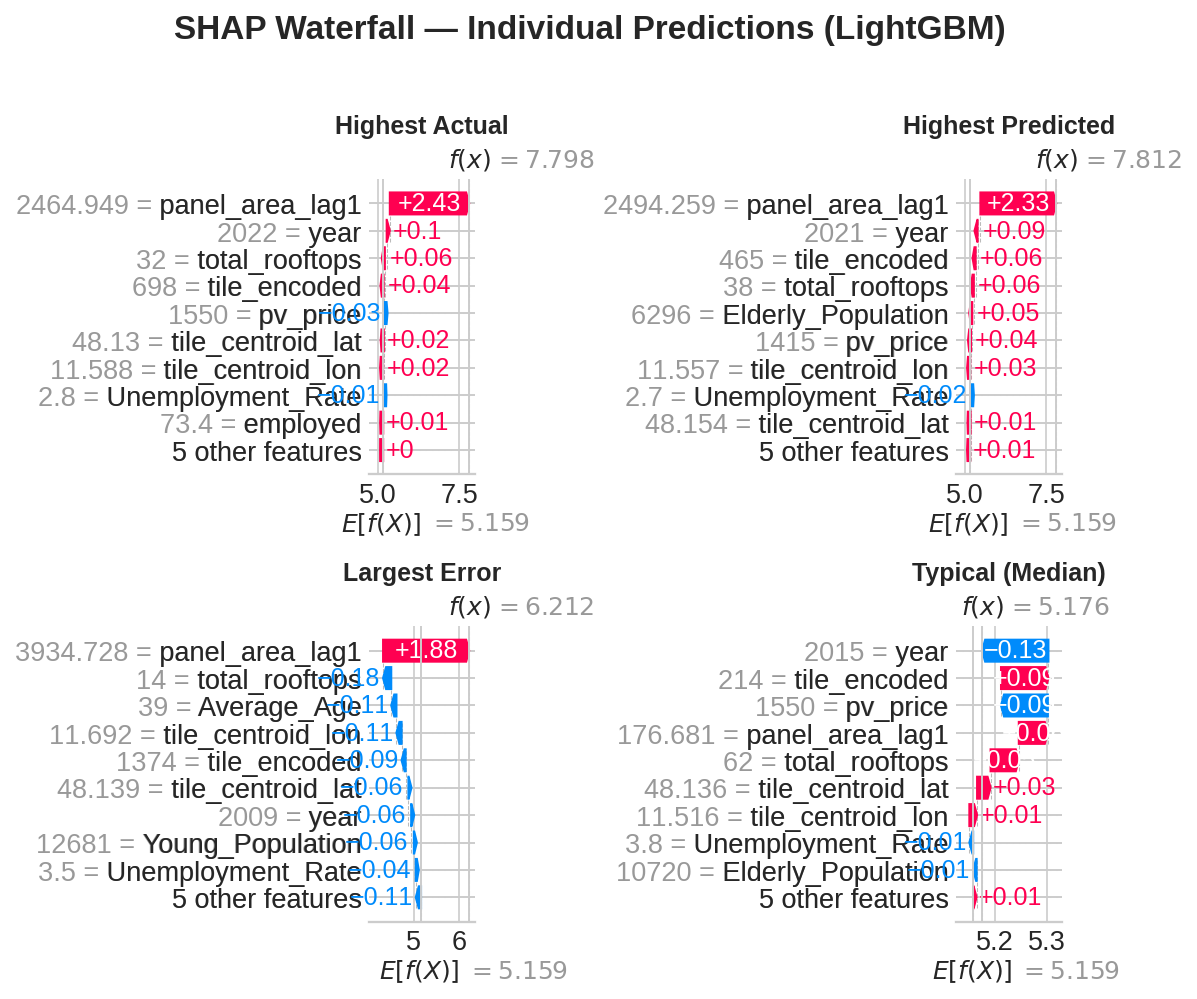

In [ ]:
sv = shap_results.get('LightGBM') or list(shap_results.values())[0]
model_label2 = 'LightGBM' if 'LightGBM' in shap_results else list(shap_results.keys())[0]

# Extract exactly what was sent to this model for SHAP
if model_label2 in ['RandomForest', 'HistGBR']:
    X_waterfall = X_shap.head(300) if len(X_shap) > 300 else X_shap
else:
    X_waterfall = X_shap

# Find interesting predictions: highest, lowest, median, most error
y_pred_shap = models[model_label2].predict(X_waterfall)
y_actual_shap = y_train.loc[X_waterfall.index]  # Safe mapping
errors = np.abs(y_actual_shap.values - y_pred_shap)

indices = {
    'Highest Actual': np.argmax(y_actual_shap.values),
    'Highest Predicted': np.argmax(y_pred_shap),
    'Largest Error': np.argmax(errors),
    'Typical (Median)': np.argsort(y_actual_shap.values)[len(y_actual_shap)//2],
}

fig = plt.figure(figsize=(20, 16))
for plot_i, (label, idx) in enumerate(indices.items(), 1):
    ax = fig.add_subplot(2, 2, plot_i)
    plt.sca(ax)
    shap.plots.waterfall(sv[idx], max_display=10, show=False)
    ax.set_title(f'{label}', fontsize=12, fontweight='bold')

plt.suptitle(f'SHAP Waterfall — Individual Predictions ({model_label2})',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'shap_waterfall_examples', tight=False)
plt.show()

---
### Figure 11: SHAP vs Built-in Importance Correlation

Quantifies how well SHAP and built-in importance agree across features.

  Saved: importance_correlation_scatter.png / .pdf


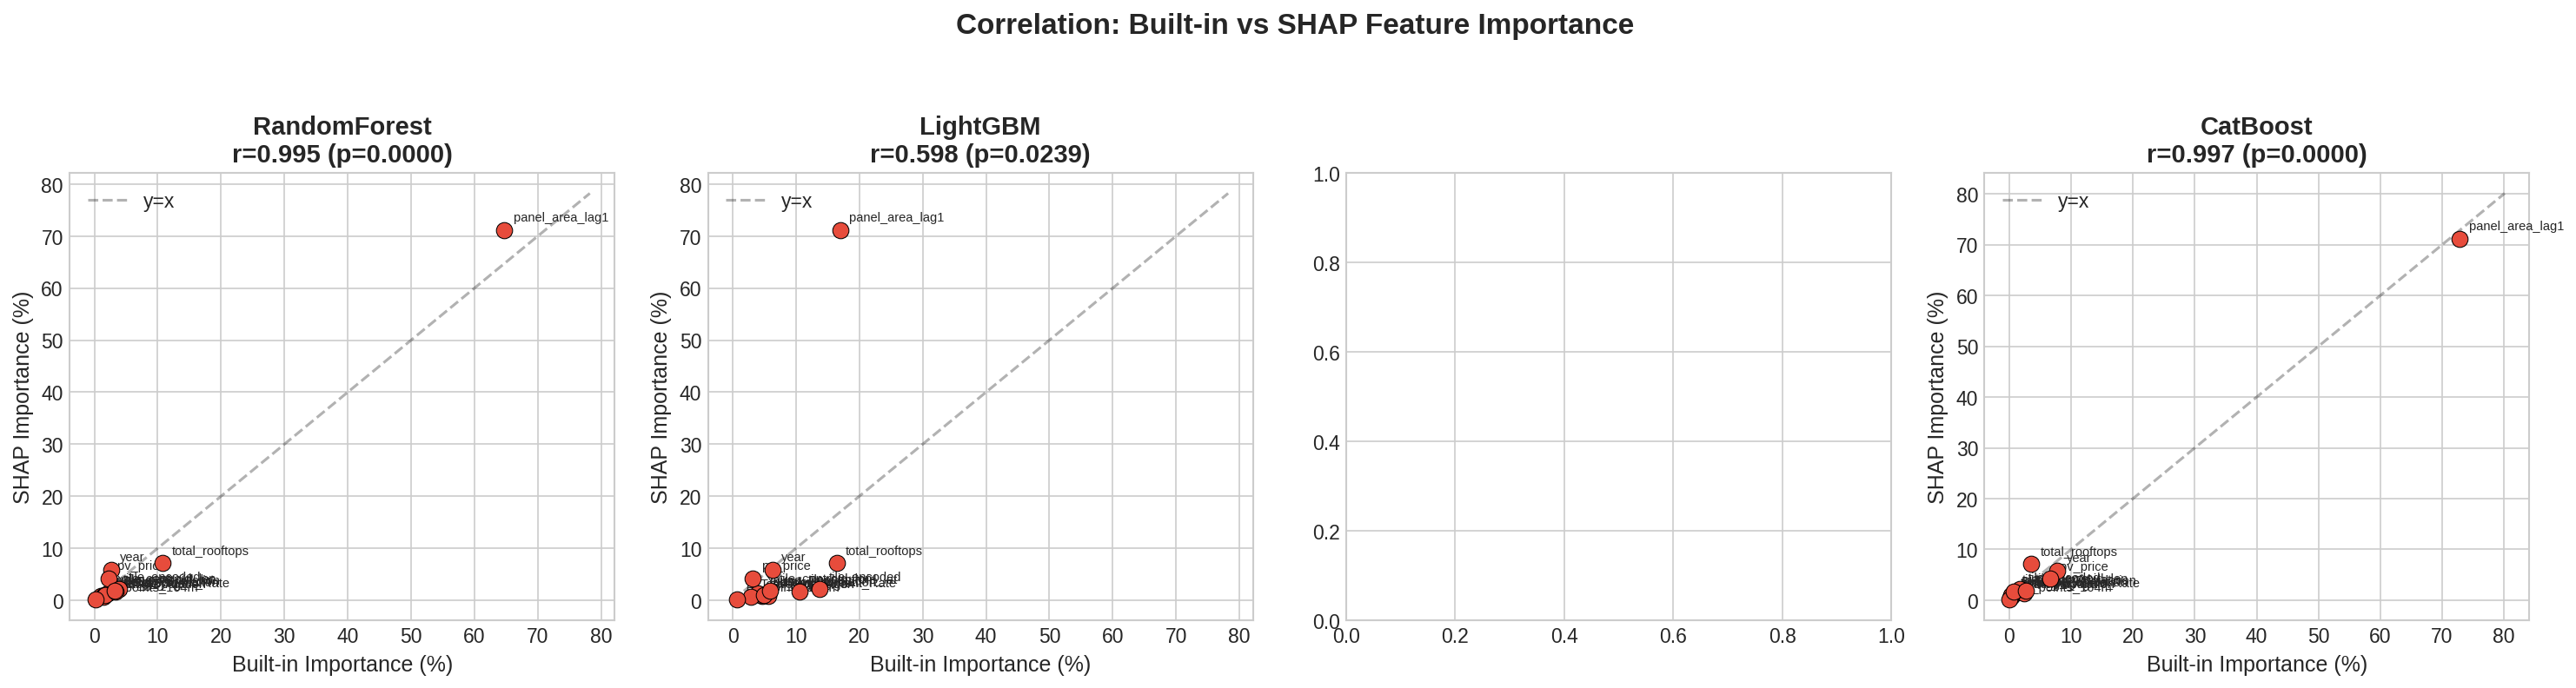

In [ ]:
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, len(shap_results), figsize=(5*len(shap_results), 5))
if len(shap_results) == 1:
    axes = [axes]

for ax, name in zip(axes, shap_results.keys()):
    if name not in builtin_importance.columns:
        continue

    x = builtin_importance.loc[FEATURE_COLS, name].values
    y = shap_importance_df.reindex(FEATURE_COLS)['Average'].values

    ax.scatter(x, y, s=80, c='#e74c3c', edgecolors='black', linewidth=0.5, zorder=5)

    # Add feature labels
    for j, feat in enumerate(FEATURE_COLS):
        ax.annotate(feat, (x[j], y[j]), fontsize=7,
                   textcoords='offset points', xytext=(5, 5))

    # Add correlation line
    r, p = pearsonr(x, y)
    max_val = max(x.max(), y.max()) * 1.1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='y=x')
    ax.set_xlabel('Built-in Importance (%)')
    ax.set_ylabel('SHAP Importance (%)')
    ax.set_title(f'{name}\nr={r:.3f} (p={p:.4f})', fontweight='bold')
    ax.legend()

plt.suptitle('Correlation: Built-in vs SHAP Feature Importance',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
save_fig(fig, 'importance_correlation_scatter', tight=False)
plt.show()

---
### Figure 12: Q-Q Plots — Residual Normality Check

  Saved: qq_plots_residuals.png / .pdf


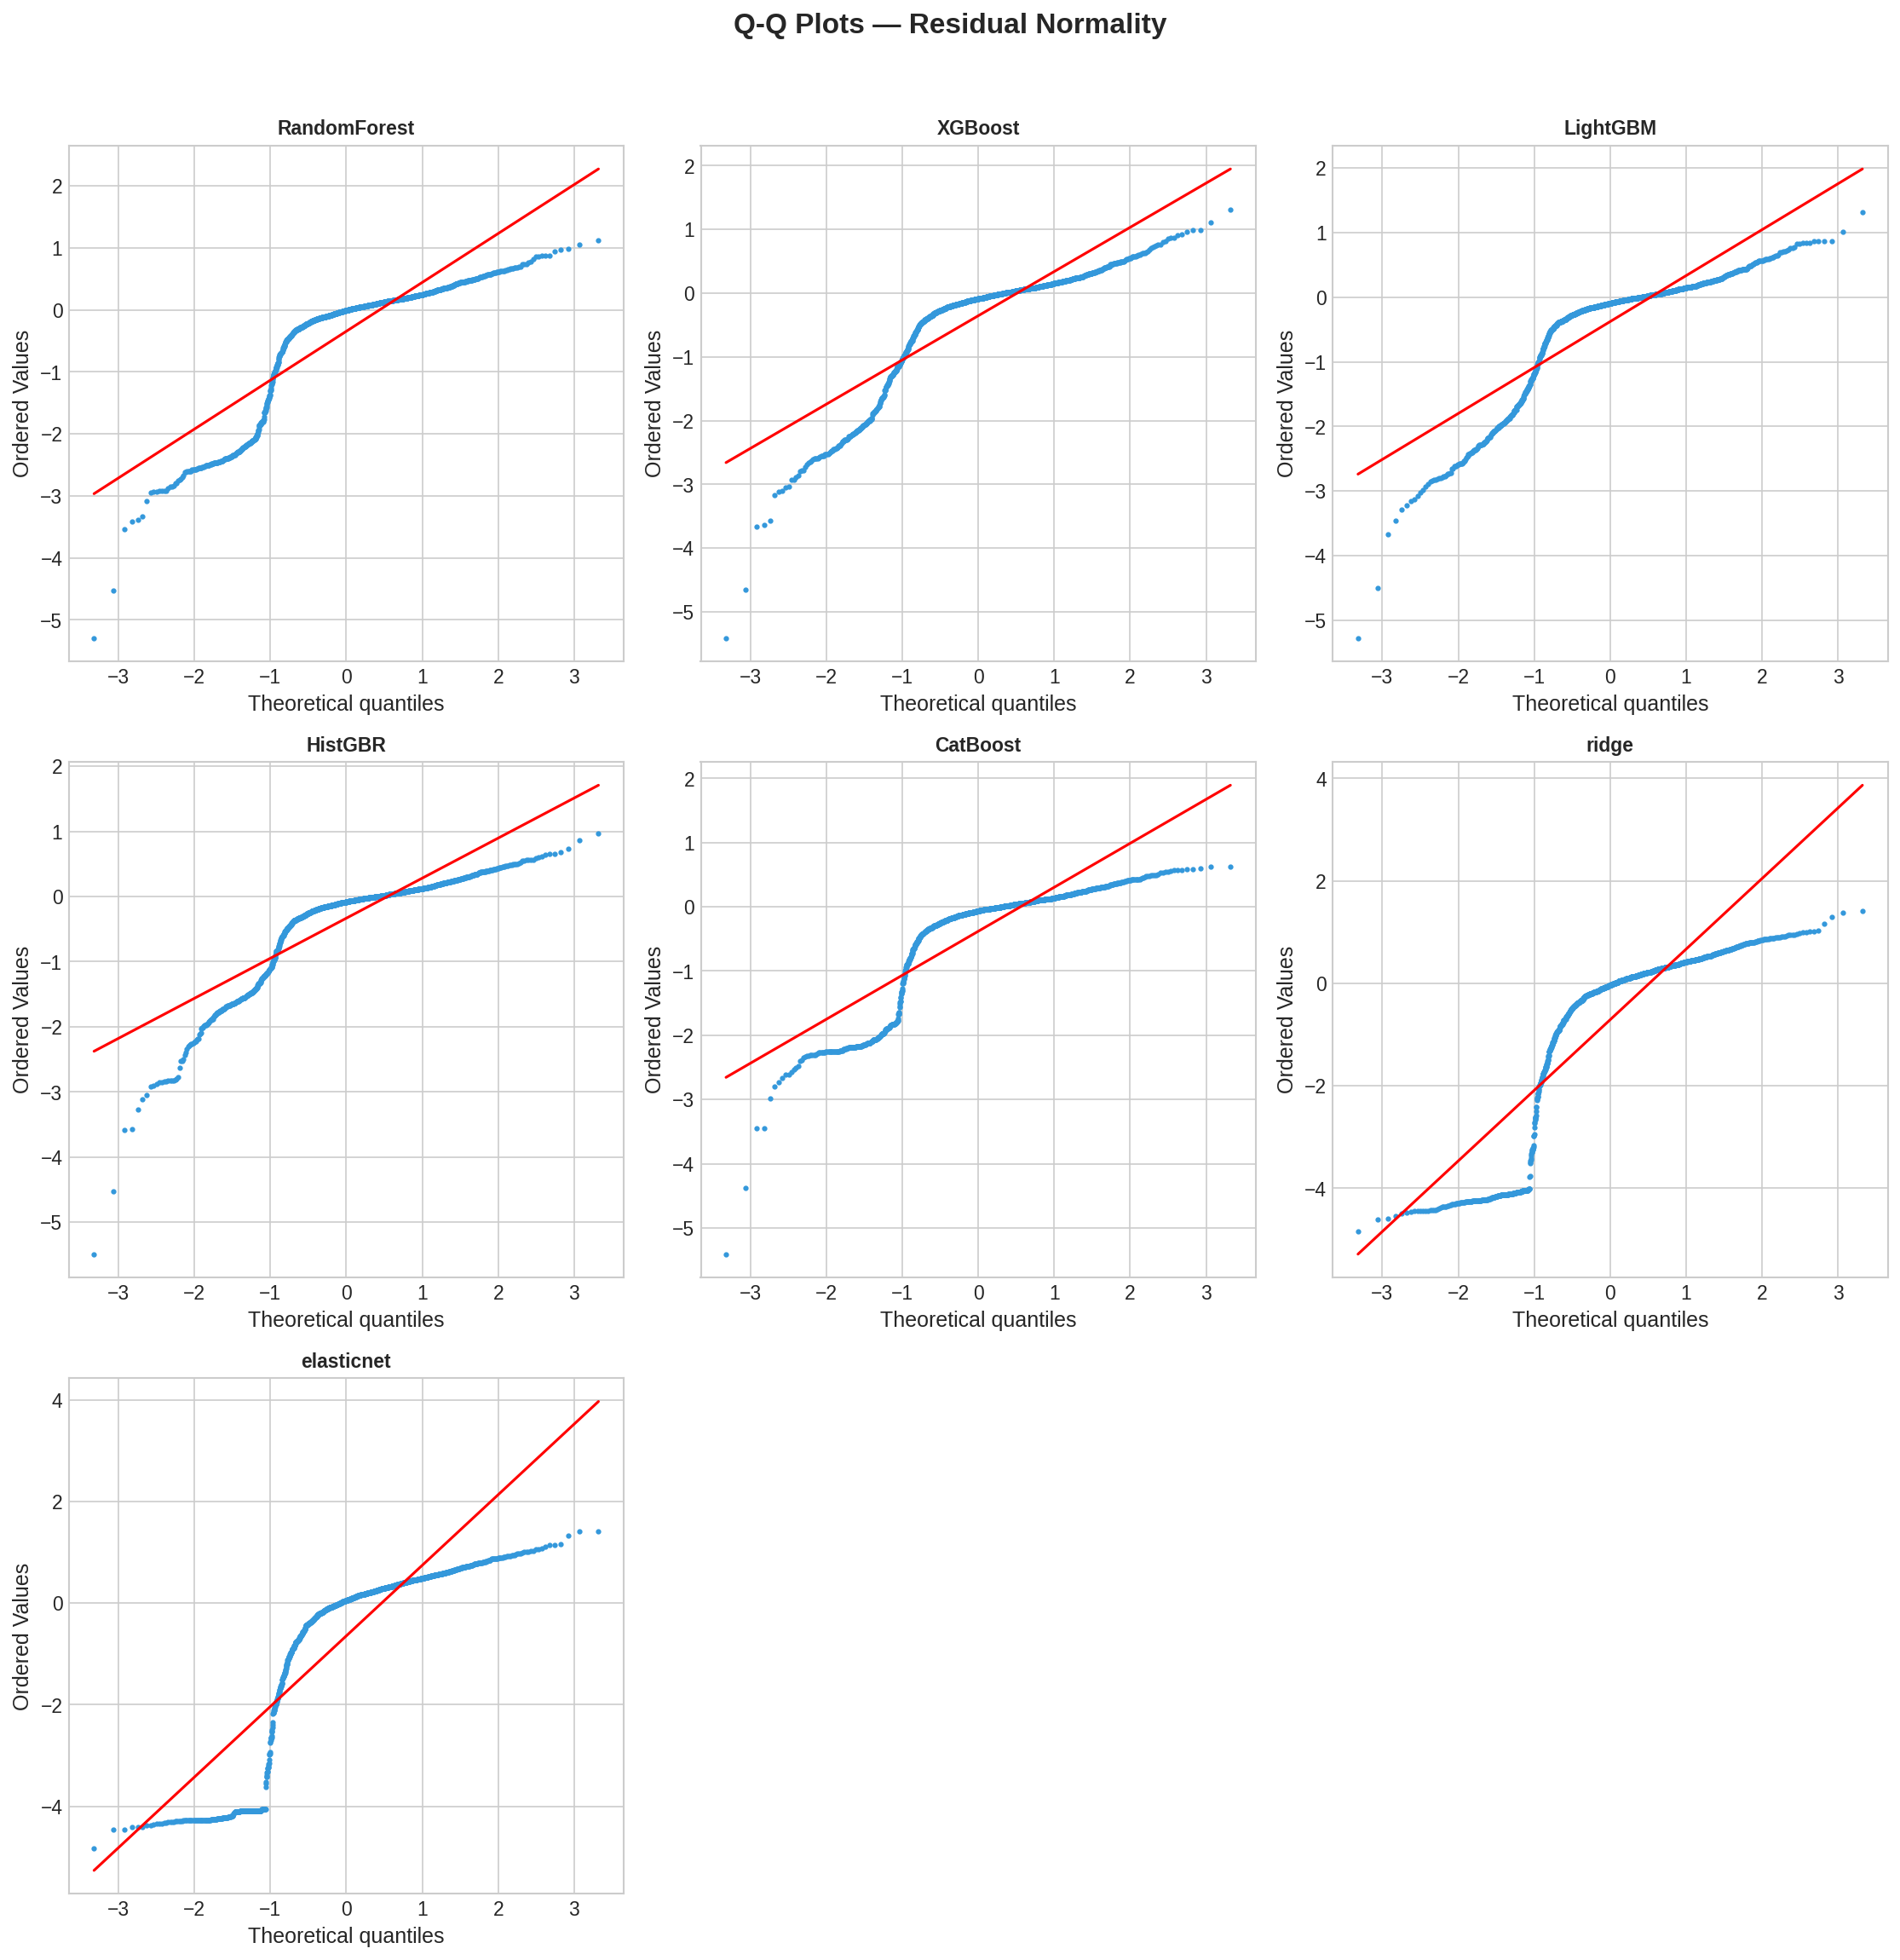

In [ ]:
ncols = 3
nrows = (len(models) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes_flat = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    ax = axes_flat[i]
    y_pred = model.predict(X_test)
    residuals = y_test.values - y_pred
    stats.probplot(residuals, dist='norm', plot=ax)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.get_lines()[0].set_marker('.')
    ax.get_lines()[0].set_markerfacecolor('#3498db')
    ax.get_lines()[0].set_markeredgecolor('#3498db')
    ax.get_lines()[0].set_markersize(4)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Q-Q Plots — Residual Normality',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'qq_plots_residuals', tight=False)
plt.show()

---
### Figure 13: Feature Correlation Heatmap

  Saved: feature_correlation_heatmap.png / .pdf


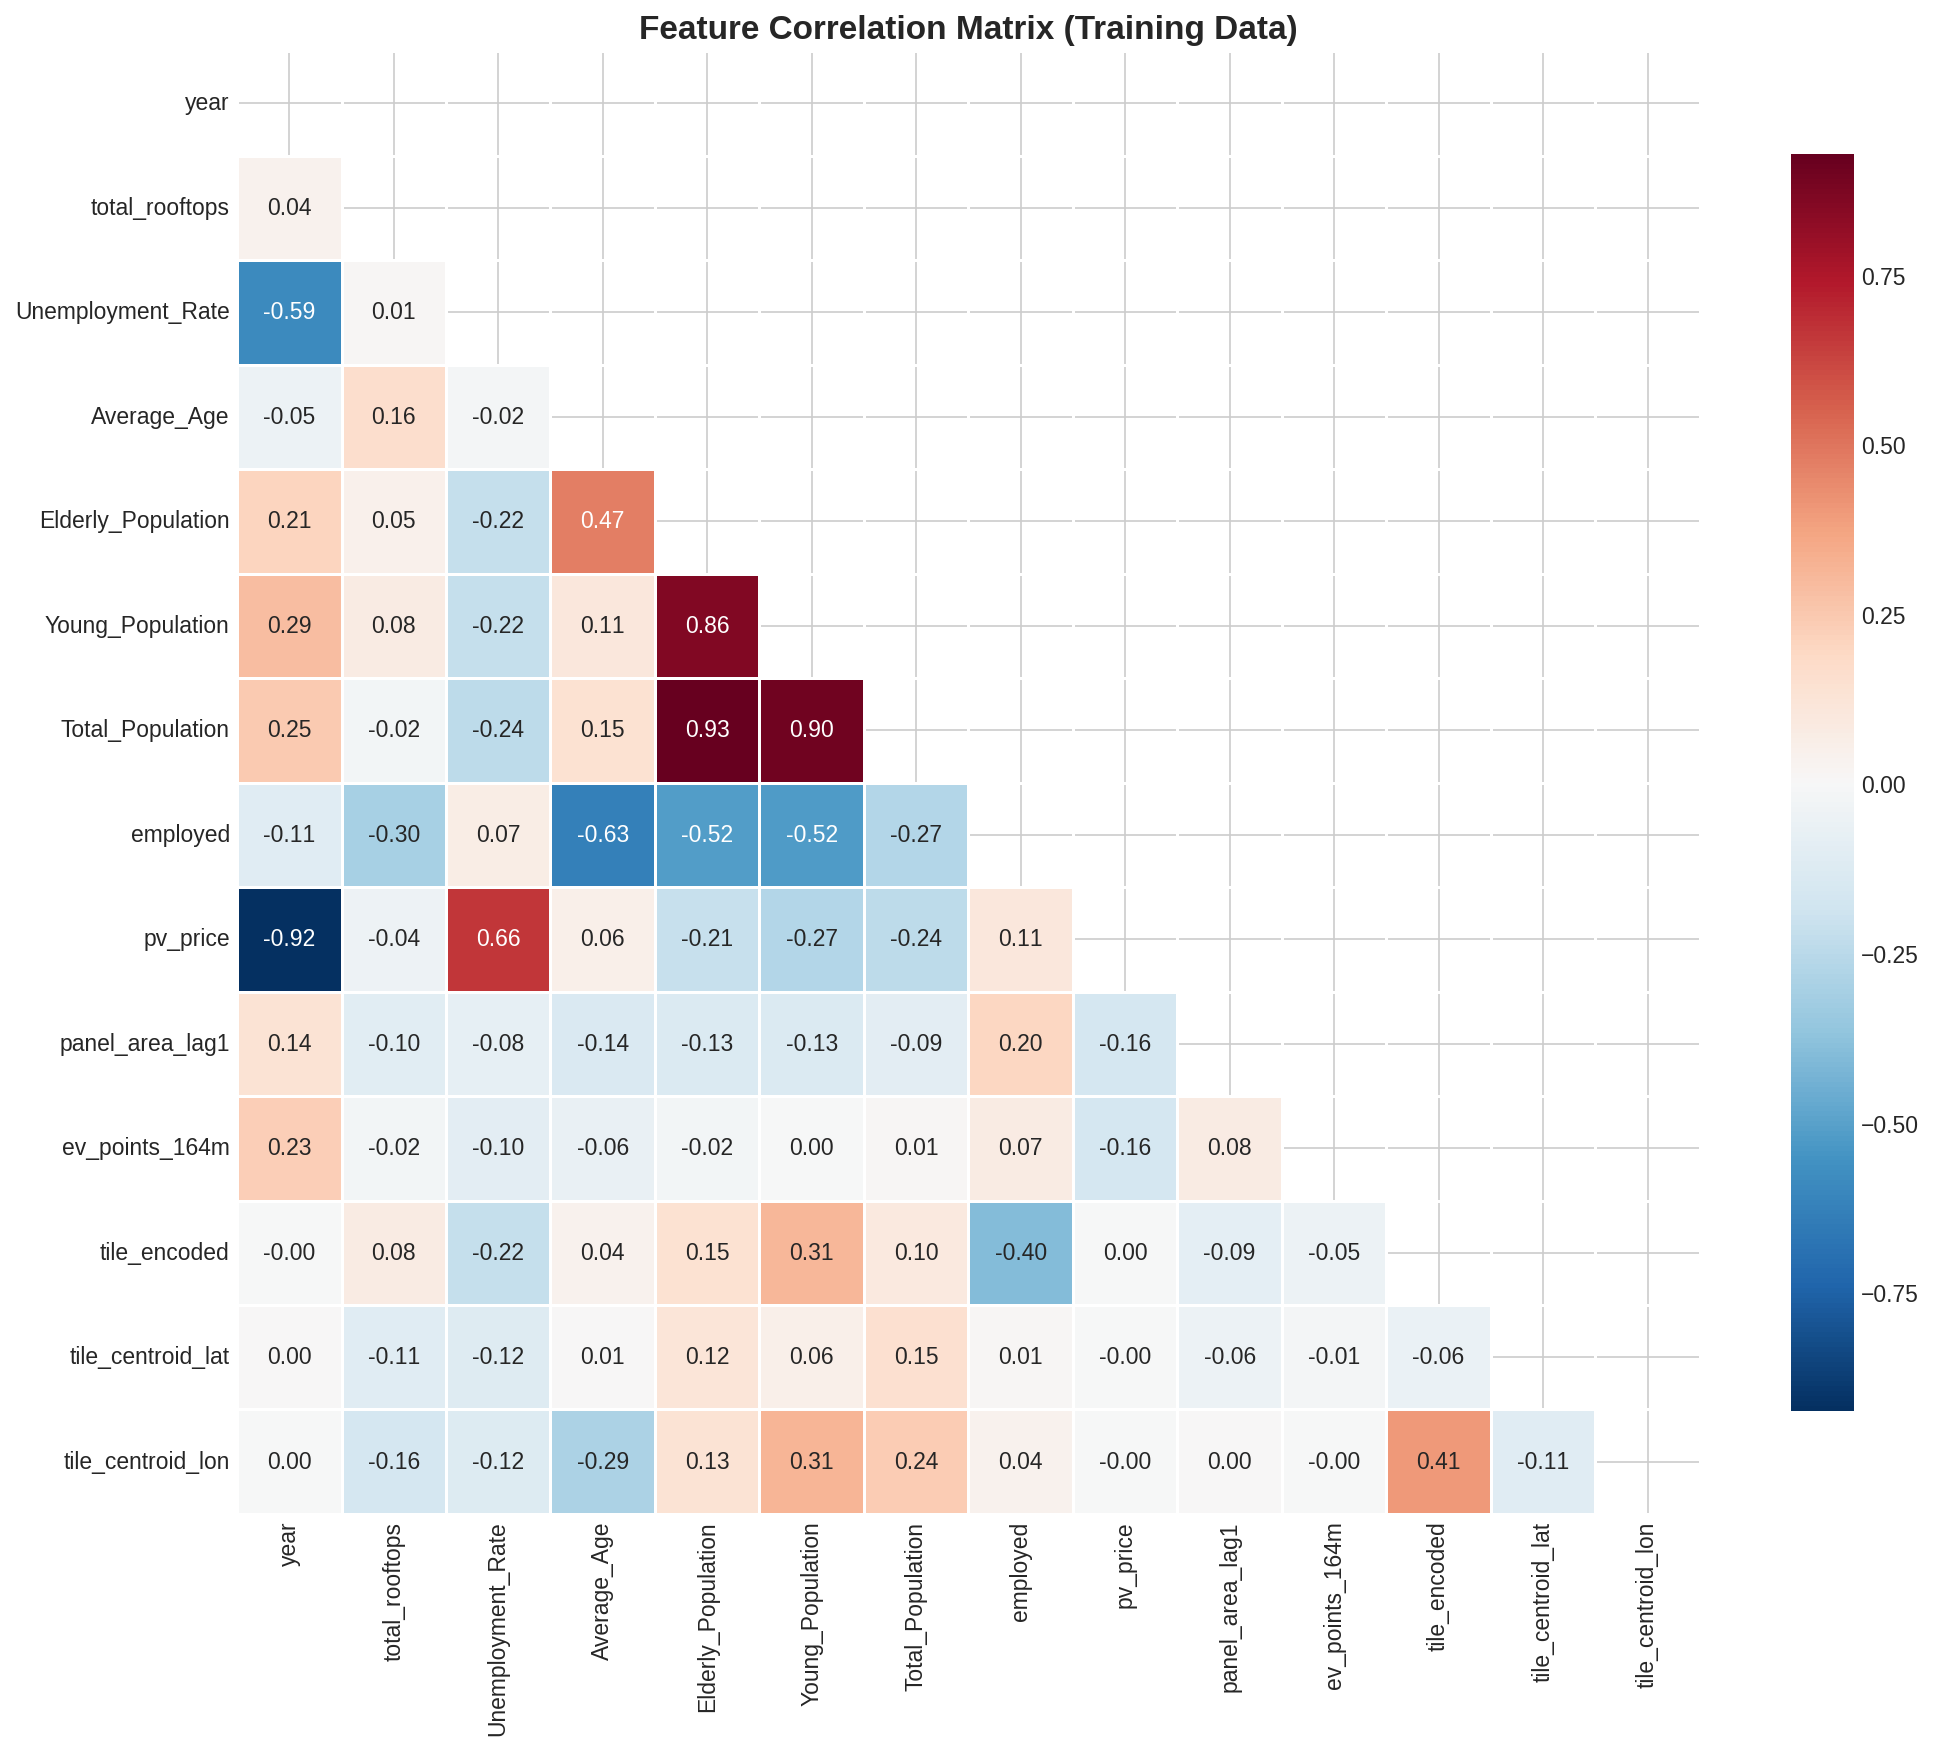

In [ ]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (Training Data)',
             fontsize=16, fontweight='bold')
save_fig(fig, 'feature_correlation_heatmap')
plt.show()

---
### Figure 14: Target Variable Distribution

  Saved: target_distribution.png / .pdf


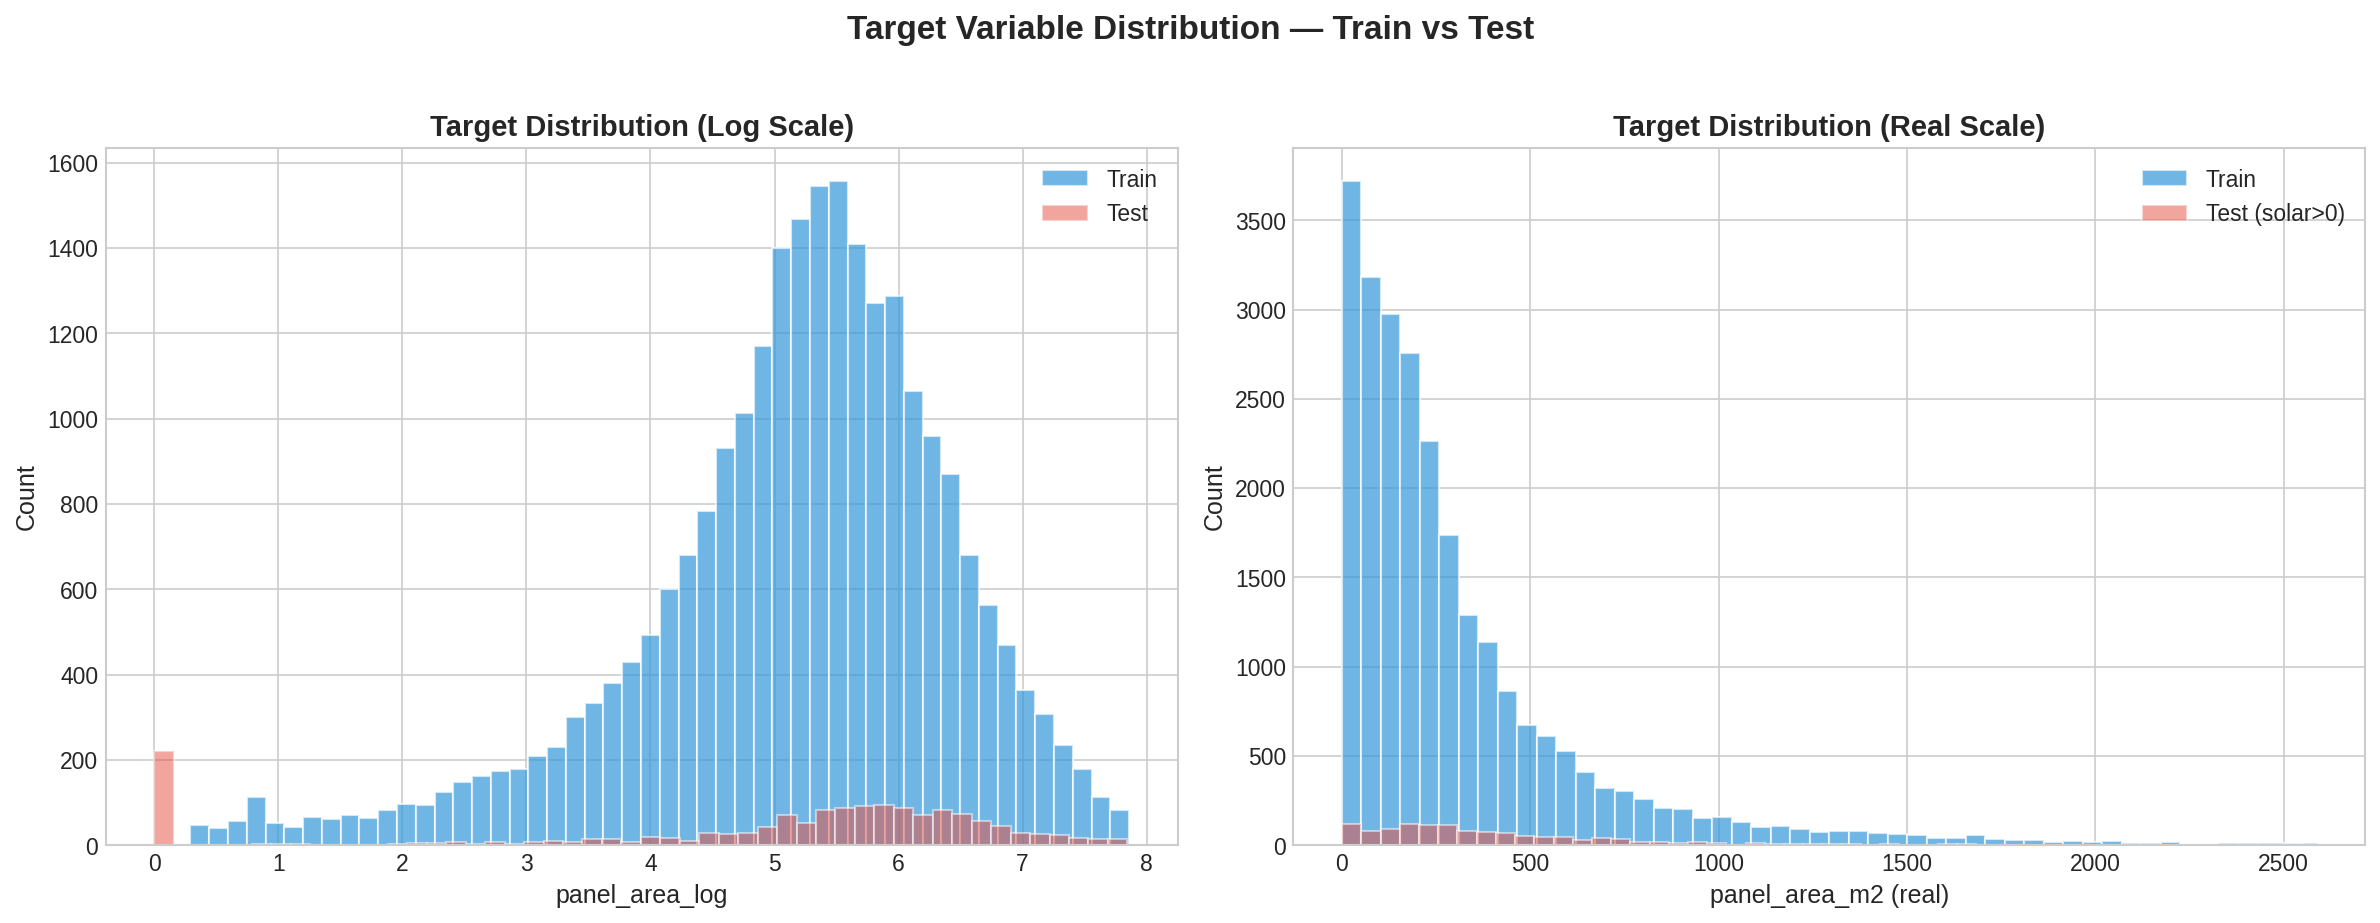

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Log scale
ax1.hist(y_train, bins=50, color='#3498db', alpha=0.7, edgecolor='white', label='Train')
ax1.hist(y_test, bins=50, color='#e74c3c', alpha=0.5, edgecolor='white', label='Test')
ax1.set_xlabel('panel_area_log')
ax1.set_ylabel('Count')
ax1.set_title('Target Distribution (Log Scale)', fontweight='bold')
ax1.legend()

# Real scale
ax2.hist(np.expm1(y_train), bins=50, color='#3498db', alpha=0.7, edgecolor='white', label='Train')
ax2.hist(np.expm1(y_test[y_test > 0]), bins=50, color='#e74c3c', alpha=0.5, edgecolor='white', label='Test (solar>0)')
ax2.set_xlabel('panel_area_m2 (real)')
ax2.set_ylabel('Count')
ax2.set_title('Target Distribution (Real Scale)', fontweight='bold')
ax2.legend()

plt.suptitle('Target Variable Distribution — Train vs Test',
             fontsize=16, fontweight='bold', y=1.02)
save_fig(fig, 'target_distribution')
plt.show()

---
### Figure 15: Permutation Importance — Heatmap Across All Models

In [ ]:
# Compute permutation importance for all models
perm_importance_df = pd.DataFrame()
for name, model in models.items():
    print(f'  Computing permutation importance for {name}...')
    perm = permutation_importance(model, X_test, y_test,
                                  n_repeats=10, random_state=42, n_jobs=-1)
    imp = perm.importances_mean
    imp = np.clip(imp, 0, None)  # clip negatives
    total = imp.sum()
    pct = (imp / total) * 100 if total > 0 else imp
    perm_importance_df[name] = pct

perm_importance_df.index = FEATURE_COLS
perm_importance_df['Average'] = perm_importance_df.mean(axis=1)
perm_importance_df = perm_importance_df.sort_values('Average', ascending=False)

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(perm_importance_df.drop(columns='Average'),
            annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Importance (%)'})
ax.set_title('Permutation Importance Across All Models (%)',
             fontsize=16, fontweight='bold')
ax.set_ylabel('Feature')
ax.set_xlabel('Model')

save_fig(fig, 'permutation_importance_heatmap')
plt.show()

# Print table
print('\nPermutation Importance (%, normalised):')
styled = perm_importance_df.style.format('{:.2f}%').background_gradient(
    cmap='YlOrRd', axis=None
)
display(styled)

  Computing permutation importance for RandomForest...


---
### Figure 16: SHAP vs Permutation Importance Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

shap_avg = shap_importance_df.reindex(FEATURE_COLS)['Average'].values
perm_avg = perm_importance_df.reindex(FEATURE_COLS)['Average'].values

ax.scatter(perm_avg, shap_avg, s=100, c='#e74c3c',
           edgecolors='black', linewidth=0.5, zorder=5)

for j, feat in enumerate(FEATURE_COLS):
    ax.annotate(feat, (perm_avg[j], shap_avg[j]), fontsize=9,
               textcoords='offset points', xytext=(5, 5))

r, p = pearsonr(perm_avg, shap_avg)
max_val = max(perm_avg.max(), shap_avg.max()) * 1.1
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label=f'y=x (r={r:.3f})')
ax.set_xlabel('Permutation Importance (%)', fontsize=13)
ax.set_ylabel('SHAP Importance (%)', fontsize=13)
ax.set_title(f'SHAP vs Permutation Importance\nPearson r = {r:.3f}, p = {p:.4f}',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

save_fig(fig, 'shap_vs_permutation_importance')
plt.show()

---
## Summary

This notebook produced the following figures for the thesis:

| # | Figure | File |
|---|--------|------|
| 1 | SHAP Beeswarm plots (per model) | `shap_beeswarm_*.png` |
| 2 | Average SHAP importance bar chart | `shap_importance_comparison_bar.png` |
| 3 | Built-in vs SHAP importance comparison | `feature_importance_vs_shap_comparison.png` |
| 4 | SHAP dependence plots (top 6 features) | `shap_dependence_top6.png` |
| 5 | Per-model SHAP importance grid | `shap_per_model_grid.png` |
| 6 | Predicted vs Actual scatter | `predicted_vs_actual_all_models.png` |
| 7 | Residual distributions | `residual_distribution_all_models.png` |
| 8 | Error vs features | `error_vs_features.png` |
| 9 | Model performance comparison | `model_performance_comparison.png` |
| 10 | SHAP waterfall examples | `shap_waterfall_examples.png` |
| 11 | SHAP vs Built-in correlation | `importance_correlation_scatter.png` |
| 12 | Q-Q plots for residuals | `qq_plots_residuals.png` |
| 13 | Feature correlation heatmap | `feature_correlation_heatmap.png` |
| 14 | Target distribution | `target_distribution.png` |
| 15 | Permutation importance heatmap | `permutation_importance_heatmap.png` |
| 16 | SHAP vs Permutation importance | `shap_vs_permutation_importance.png` |

All figures saved in both PNG (300 DPI) and PDF formats in the `figures/` directory.